In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso
from scipy.optimize import nnls, minimize
import yfinance as yf


## テーマETFの戦略設計
テーマETFの価格形成は以下の要因と仮定
$$R_{i,t}=\beta_iF_t+\theta_i Theme_i+\epsilon_{i,t}$$
$F_T$: 市場ファクター、$T_t$: テーマ固有トレンド、$\theta_i$: テーマ感応度

テーマトレンド検出＋ETF選択

In [2]:
CONFIG = {
    # Data scope
    'start_date': '2010-07-23',
    'end_date': None,
    'tickers': [
        'AGNG','AIQ','AQWA','BITS','BKCH','BOTZ','BUG','CHPX','CLOU','CTEC','DRIV','DTCR',
        'EBIZ','FINX','GNOM','HEAL','HERO','HYDR','IPAV','KROP','LIT','MILN','PAVE','RNRG',
        'SHLD','SNSR','SOCL','ZAP'
    ],
    #'tickers': [
    #    "XLB","XLE","XLF","XLI","XLK","XLP","XLU","XLV","XLY",
    #],
    'local_csv_path': 'data/theme_etf.csv',
    #'local_csv_path': 'data/sector_etf.csv',
    'rebalance': 'W-FRI',  # 'M' or 'W-FRI'

    'cost_bps': 10,
    'benchmark': 'EQW',

    # Factor construction (monthly meaning; converted to runtime periods)
    #'factor_method': 'pca',
    'pca_window_months': 60,
    'n_components': 8,
    #'standardize': True,
    'min_obs_per_window': 24,

    # Factor momentum (monthly meaning; converted to runtime periods)
    'factor_mom_lookbacks': [1, 12],
    'factor_mom_skip_months': 1,   # 12-1 style in monthly meaning
    'combine_weights': {1: 0.5, 12: 0.5},
    'factor_weighting': 'top_m',   # 'top_m' | 'rank' | 'sign'
    'top_m_factors': 3,
    'exclude_pcs': [1],

    # ETF mapping (monthly meaning; converted to runtime periods)
    #'etf_mapping_modes': ['loadings', 'regression'],
    'regression_window_months': 60,

    # Portfolio constraints
    'long_only': True,
    'weight_cap': None,

    # Sign-aware ETF mapping
    'etf_weight_mode': 'proportional',  # 'proportional' | 'topk_equal'
    'etf_top_k': 5,
    'factor_select_by_abs_mom': True,
    'run_sign_aware': True,

    # Sign-aware comparison matrix
    'compare_weight_methods': ['proportional', 'topk_equal', 'vol_adjusted', 'meanvariance_tc'],
    'compare_full_matrix': True,

    # Regularized rolling exposure (S2-R-SA)
    's2r_exposure_models': ['ridge', 'lasso', 'nnls'],
    'exposure_standardize_x': True,
    'ridge_alpha': 5.0,
    'lasso_alpha': 0.001,
    'lasso_max_iter': 10000,
    'nnls_fit_intercept': True,

    # Post-mapping weight methods
    'vol_window_months': 6,
    'cov_window_months': 12,
    'cov_shrinkage': 0.2,
    'mv_risk_aversion': 10.0,
    'mv_turnover_penalty': 5.0,
    'mv_abs_eps': 1e-8,
    'mv_solver_maxiter': 300,

    # Theme heat integration
    'run_theme_heat_variants': True,
    'heat_dispersion_weight': 0.3333333333,
    'heat_breadth_weight': 0.3333333333,
    'heat_volume_weight': 0.3333333333,
    'heat_signal_alpha': 0.50,
    'heat_alloc_beta': 0.50,
    'heat_signal_floor': 0.20,
    'heat_local_blend': 0.50,
    'heat_norm_lookback_months': 24,
    'heat_norm_min_periods_months': 12,
    'heat_volume_z_window_months': 6,
    'heat_suffix': 'HEAT',
}

def load_data(config):
    tickers = config['tickers']
    start = pd.to_datetime(config['start_date']) if config.get('start_date') else None
    end = pd.to_datetime(config['end_date']) if config.get('end_date') else None

    raw = pd.read_csv(config['local_csv_path'], header=[0, 1], index_col=0, parse_dates=True)
    px_d = raw['Adj Close'].copy()
    vol_d = raw['Volume'].copy() if 'Volume' in raw.columns.get_level_values(0) else pd.DataFrame(index=px_d.index, columns=px_d.columns)
    
    px_d = px_d.reindex(columns=tickers)
    vol_d = vol_d.reindex(columns=tickers)
    px_d = px_d.sort_index()
    vol_d = vol_d.sort_index()

    if start is not None:
        px_d = px_d.loc[px_d.index >= start]
        vol_d = vol_d.loc[vol_d.index >= start]
    if end is not None:
        px_d = px_d.loc[px_d.index <= end]
        vol_d = vol_d.loc[vol_d.index <= end]

    return px_d, vol_d

px_d, vol_d = load_data(CONFIG)

In [3]:

missing_ratio = px_d.isna().mean().sort_values(ascending=False)
summary = pd.DataFrame({
    'missing_ratio': missing_ratio,
    'non_null_days': px_d.notna().sum(),
})

print('Data source:', 'yfinance' if CONFIG.get('use_yfinance', False) else CONFIG['local_csv_path'])
print(f'Daily date range: {px_d.index.min().date()} -> {px_d.index.max().date()}')
print(f'Ticker count: {px_d.shape[1]}')
display(summary.head(10))

px_d.tail()

Data source: data/theme_etf.csv
Daily date range: 2010-07-23 -> 2026-02-27
Ticker count: 28


,missing_ratio,non_null_days
Ticker,,
AGNG,0.371814,2465
AIQ,0.501274,1957
AQWA,0.687309,1227
BITS,0.726300,1074
BKCH,0.703874,1162
BOTZ,0.393986,2378
BUG,0.595311,1588
CHPX,0.973751,103
CLOU,0.559888,1727


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-23,38.439999,48.529999,20.485001,53.153000,61.709999,38.580002,24.299999,60.896999,18.110001,59.659000,...,33.514999,36.112000,73.779999,41.917000,54.860001,37.345001,74.339996,39.659000,49.270000,32.860001
2026-02-24,38.341000,49.490002,20.777000,54.736000,64.849998,39.009998,24.370001,62.669998,18.559999,61.338001,...,33.756001,36.473000,75.589996,42.430000,55.650002,37.375000,74.889999,40.535000,49.139999,33.290001
2026-02-25,38.428001,50.549999,20.802999,57.162998,66.320000,39.660000,24.980000,63.900002,18.799999,61.584999,...,33.990002,36.344002,77.089996,42.840000,55.070000,37.563999,73.919998,40.921001,49.490002,33.400002
2026-02-26,37.990002,50.520000,20.893999,56.136002,65.470001,39.500000,25.690001,62.283001,19.010000,59.637001,...,33.930000,36.252998,75.769997,43.542999,55.330002,37.431999,74.339996,40.915001,49.450001,33.250000
2026-02-27,38.349998,50.259998,20.815001,53.895000,62.299999,39.020000,25.110001,61.930000,18.760000,58.603001,...,33.922001,36.794998,75.400002,43.467999,55.090000,36.955002,74.860001,40.613998,49.330002,33.349998


In [4]:
def _convert_months_to_periods(month_value, scale):
    return max(1, int(round(float(month_value) * scale)))

def resolve_runtime_params(config):
    rebalance = str(config.get('rebalance', 'M')).upper()
    if rebalance == 'M':
        rule = 'ME'
        periods_per_year = 12
        scale = 1.0
        frequency_label = 'Monthly (EOM)'
    elif rebalance.startswith('W-'):
        rule = rebalance
        periods_per_year = 52
        scale = 52.0 / 12.0
        frequency_label = f'Weekly ({rebalance})'
    else:
        raise ValueError("rebalance must be 'M' or 'W-XXX' (e.g., W-FRI, W-WED).")

    pca_window = _convert_months_to_periods(config['pca_window_months'], scale)
    reg_window = _convert_months_to_periods(config['regression_window_months'], scale)
    min_obs = _convert_months_to_periods(config['min_obs_per_window'], scale)
    skip_periods = _convert_months_to_periods(config['factor_mom_skip_months'], scale)

    lookbacks_months = [int(x) for x in config['factor_mom_lookbacks']]
    lookbacks_periods = [_convert_months_to_periods(x, scale) for x in lookbacks_months]

    # 変換後lookbackが重複する場合はweightを合算
    raw_cw = {int(k): float(v) for k, v in config['combine_weights'].items()}
    combined = {}
    for lb_month, lb_period in zip(lookbacks_months, lookbacks_periods):
        w = raw_cw.get(lb_month, 0.0)
        combined[lb_period] = combined.get(lb_period, 0.0) + w

    if sum(combined.values()) == 0:
        unique_lb = sorted(set(lookbacks_periods))
        combined = {lb: 1.0 / len(unique_lb) for lb in unique_lb}
    else:
        s = sum(combined.values())
        combined = {k: v / s for k, v in combined.items()}

    lookbacks_periods = sorted(set(lookbacks_periods))

    return {
        'rebalance': rebalance,
        'rule': rule,
        'periods_per_year': periods_per_year,
        'scale': scale,
        'frequency_label': frequency_label,
        'pca_window': pca_window,
        'reg_window': reg_window,
        'min_obs': min_obs,
        'skip_periods': skip_periods,
        'lookbacks_periods': lookbacks_periods,
        'combine_weights_periods': combined,
        'lookback_month_to_period': dict(zip(lookbacks_months, [_convert_months_to_periods(x, scale) for x in lookbacks_months])),
    }

## Daily -> Periodic (ME or W-FRI)
def to_periodic(px_d, vol_d, rule):
    px_p = px_d.resample(rule).last()
    vol_p = vol_d.resample(rule).sum(min_count=1)
    ret_p = px_p.pct_change()
    return px_p, ret_p, vol_p


RUNTIME = resolve_runtime_params(CONFIG)
px_p, ret_p, vol_p = to_periodic(px_d, vol_d, RUNTIME['rule'])


print(f"Rebalance mode: {RUNTIME['frequency_label']} (rule={RUNTIME['rule']})")
print('Timing: decide at period-end t and apply to next period return (t+1)')
print(f"Periodic range: {ret_p.index.min().date()} -> {ret_p.index.max().date()} (obs={len(ret_p)})")
print('Periodic return panel shape:', ret_p.shape)

ret_p.iloc[-5:, :8]

Rebalance mode: Weekly (W-FRI) (rule=W-FRI)
Timing: decide at period-end t and apply to next period return (t+1)
Periodic range: 2010-07-23 -> 2026-02-27 (obs=815)
Periodic return panel shape: (815, 28)


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX
Date,,,,,,,,
2026-01-30,-0.004314,-0.010284,0.002569,-0.076999,-0.086019,-0.011914,-0.036351,0.003844
2026-02-06,0.017168,-0.036367,0.024823,-0.136989,-0.116047,0.004287,-0.059029,0.004429
2026-02-13,0.014189,-0.012580,0.021770,0.003268,0.021985,0.022946,0.035264,0.010360
2026-02-20,0.003412,0.008696,-0.012525,-0.037545,-0.053319,0.017736,-0.083184,0.014011
2026-02-27,0.003218,0.007618,0.011517,-0.008755,0.011199,0.000000,-0.017990,0.002022


In [5]:
def resolve_compare_runtime_params(config, runtime):
    scale = runtime['scale']
    return {
        'vol_window_periods': _convert_months_to_periods(config.get('vol_window_months', 6), scale),
        'cov_window_periods': _convert_months_to_periods(config.get('cov_window_months', 12), scale),
        'heat_norm_lookback_periods': _convert_months_to_periods(config.get('heat_norm_lookback_months', 24), scale),
        'heat_norm_min_periods': _convert_months_to_periods(config.get('heat_norm_min_periods_months', 12), scale),
        'heat_volume_z_window_periods': _convert_months_to_periods(config.get('heat_volume_z_window_months', 6), scale),
    }


RUNTIME_EX = resolve_compare_runtime_params(CONFIG, RUNTIME)
print('Compare runtime params:', RUNTIME_EX)


Compare runtime params: {'vol_window_periods': 26, 'cov_window_periods': 52}


In [6]:
RUNTIME

{'rebalance': 'W-FRI',
 'rule': 'W-FRI',
 'periods_per_year': 52,
 'scale': 4.333333333333333,
 'frequency_label': 'Weekly (W-FRI)',
 'pca_window': 260,
 'reg_window': 260,
 'min_obs': 104,
 'skip_periods': 4,
 'lookbacks_periods': [4, 52],
 'combine_weights_periods': {4: 0.5, 52: 0.5},
 'lookback_month_to_period': {1: 4, 12: 52}}

In [7]:
## 5) Rolling PCA factor construction

def build_rolling_pca(ret_p, runtime):
    window = runtime['pca_window']
    n_components = CONFIG['n_components']
    standardize = CONFIG.get('standardize', True)
    min_obs = runtime['min_obs']

    factor_cols = [f'F{i+1}' for i in range(n_components)]
    factor_ret = pd.DataFrame(index=ret_p.index, columns=factor_cols, dtype=float)

    loadings_by_t = {}
    elig_count = pd.Series(index=ret_p.index, dtype=float)
    eligibility_mask_by_t = {}

    prev_loadings = None

    for i, t in enumerate(ret_p.index):
        if i < window - 1:
            continue

        win = ret_p.iloc[i - window + 1 : i + 1]
        obs = win.notna().sum()
        elig = obs >= min_obs
        elig = elig.reindex(ret_p.columns).fillna(False)
        # 決定期tで観測不能なETFは投資対象外
        elig = elig & ret_p.loc[t].notna().reindex(ret_p.columns).fillna(False)

        eligibility_mask_by_t[t] = elig
        elig_count.loc[t] = int(elig.sum())

        if int(elig.sum()) < 2:
            continue

        x = win.loc[:, elig.index[elig.values]].copy()

        # 窓内のみで欠損補完（未来情報不使用）
        x = x.apply(lambda col: col.fillna(col.mean()), axis=0)
        x = x.fillna(0.0)

        if standardize:
            mu = x.mean(axis=0)
            sd = x.std(axis=0, ddof=0).replace(0.0, 1.0)
            x_std = (x - mu) / sd
        else:
            x_std = x

        k = min(n_components, x_std.shape[1], x_std.shape[0])
        if k < 1:
            continue

        pca = PCA(n_components=k, random_state=42)
        scores = pca.fit_transform(x_std.values)
        loadings = pd.DataFrame(pca.components_.T, index=x_std.columns, columns=[f'F{i+1}' for i in range(k)])

        # PCA符号の時系列整合
        if prev_loadings is not None:
            common_assets = loadings.index.intersection(prev_loadings.index)
            common_factors = loadings.columns.intersection(prev_loadings.columns)
            for fc in common_factors:
                if len(common_assets) == 0:
                    continue
                sign_anchor = float((loadings.loc[common_assets, fc] * prev_loadings.loc[common_assets, fc]).sum())
                if sign_anchor < 0:
                    loadings[fc] *= -1.0
                    col_idx = list(loadings.columns).index(fc)
                    scores[:, col_idx] *= -1.0

        prev_loadings = loadings.copy()

        f_t = pd.Series(scores[-1, :], index=loadings.columns)
        factor_ret.loc[t, f_t.index] = f_t.values
        loadings_by_t[t] = loadings

    elig_count = elig_count.fillna(0).astype(int).rename('eligible_count_pca')
    elig_count.attrs['eligibility_mask_by_t'] = eligibility_mask_by_t

    return factor_ret, loadings_by_t, elig_count

factor_ret, loadings_by_t, elig_pca_count = build_rolling_pca(ret_p, RUNTIME)

## factor_ret（因子リターン）の時系列

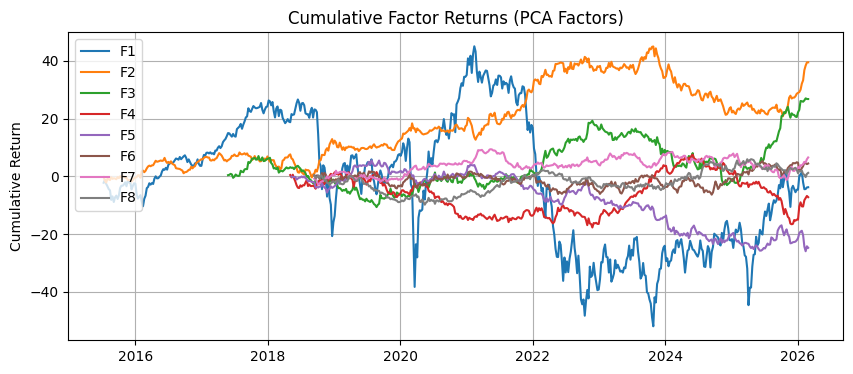

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    factor_ret.cumsum(), label=factor_ret.columns
)
ax.set_title("Cumulative Factor Returns (PCA Factors)")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid()
plt.show()

## loadings（ETF→因子）のヒートマップ

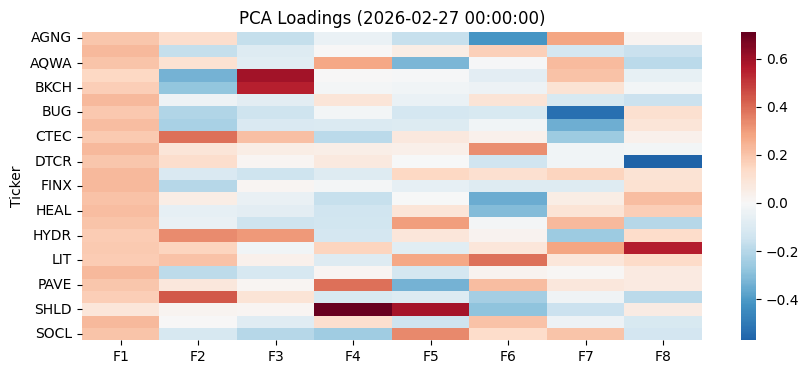

In [9]:
import seaborn as sns
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
plt.figure(figsize=(10, 4))
sns.heatmap(
    L,
    cmap="RdBu_r",
    center=0
)
plt.title(f"PCA Loadings ({latest_t})")
plt.show()

## loadings の時間推移

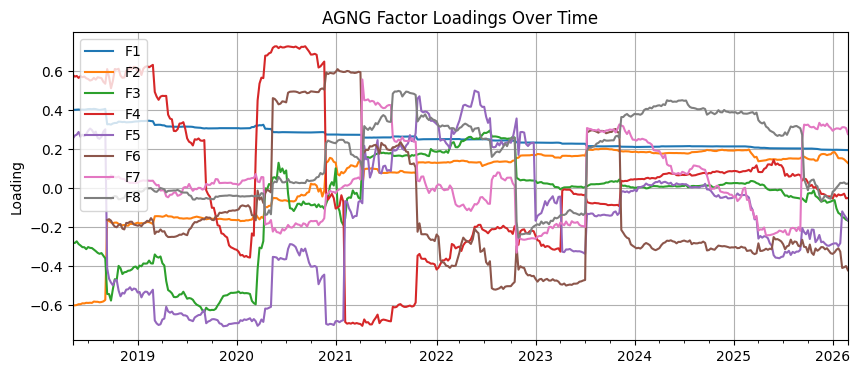

In [10]:
etf = CONFIG["tickers"][0]
series = []
for t, L in loadings_by_t.items():
    if etf in L.index:
        s = L.loc[etf]
        s.name = t
        series.append(s)

df = pd.DataFrame(series)
df.plot(figsize=(10, 4))
plt.title(f"{etf} Factor Loadings Over Time")
plt.ylabel("Loading")
plt.grid()
plt.show()

## 因子の寄与（どのETFが支配しているか）

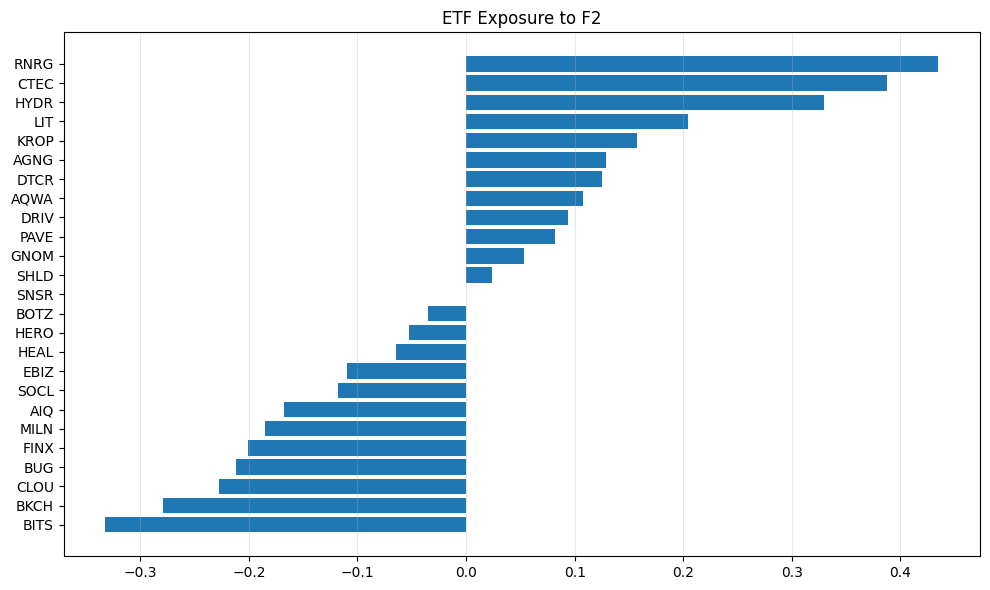

In [11]:
pc = "F2"
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
s = L[pc].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(s.index.astype(str), s.values)
ax.set_title(f"ETF Exposure to {pc}")
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
ret_p

Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.036047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.036593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.060764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-30,-0.004314,-0.010284,0.002569,-0.076999,-0.086019,-0.011914,-0.036351,0.003844,-0.037348,-0.014171,...,0.007315,0.000574,-0.064214,-0.031838,-0.006849,0.002940,-0.021841,-0.012328,-0.032537,0.015527
2026-02-06,0.017168,-0.036367,0.024823,-0.136989,-0.116047,0.004287,-0.059029,0.004429,-0.064500,-0.019069,...,0.045649,0.034434,0.016297,-0.033432,0.077635,0.014296,-0.031632,0.031709,-0.078354,0.007482
2026-02-13,0.014189,-0.012580,0.021770,0.003268,0.021985,0.022946,0.035264,0.010360,0.017107,-0.020802,...,0.010646,0.047670,0.022647,-0.046434,0.007863,0.015773,-0.008921,0.024531,-0.039208,0.057798


## 因子説明力

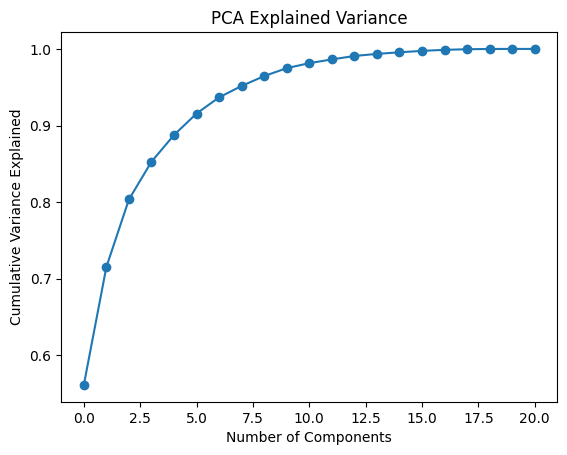

In [13]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(ret_p.dropna())
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.ylabel("Cumulative Variance Explained")
plt.xlabel("Number of Components")
plt.title("PCA Explained Variance")
plt.show()

## 因子リターン vs ETF

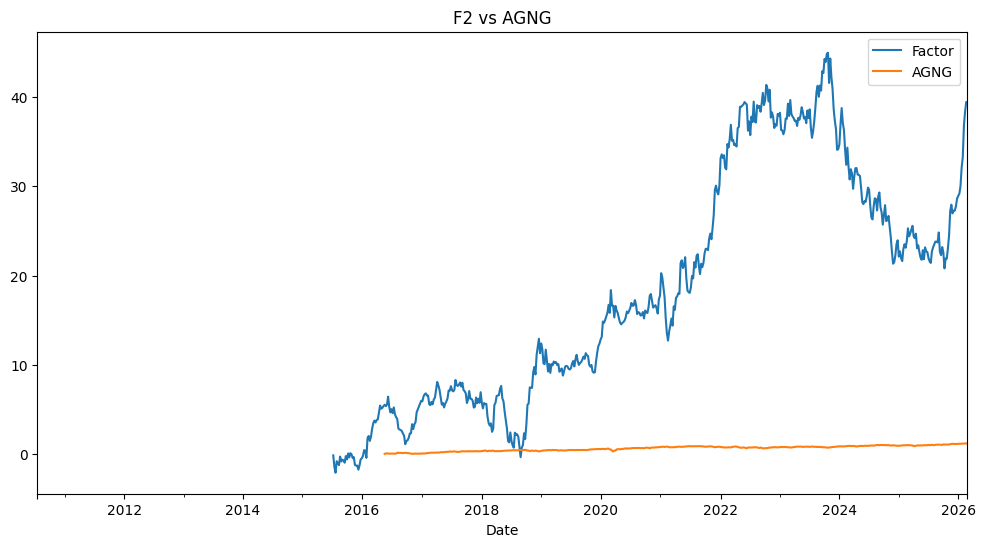

In [14]:
pc = "F2"
etf = CONFIG["tickers"][0]
fig, ax = plt.subplots(figsize=(12,6))
factor_ret[pc].cumsum().plot(ax=ax, label="Factor")
ret_p[etf].cumsum().plot(ax=ax, label=etf)
ax.legend()
ax.set_title(f"{pc} vs {etf}")
plt.show()

## Factor Breadth
どれだけ多くの因子が同時に上昇しているか
$$Breadth_t=\frac{1}{K}\sum_{k=1}^K 1(f_{k,t}\gt 0)$$

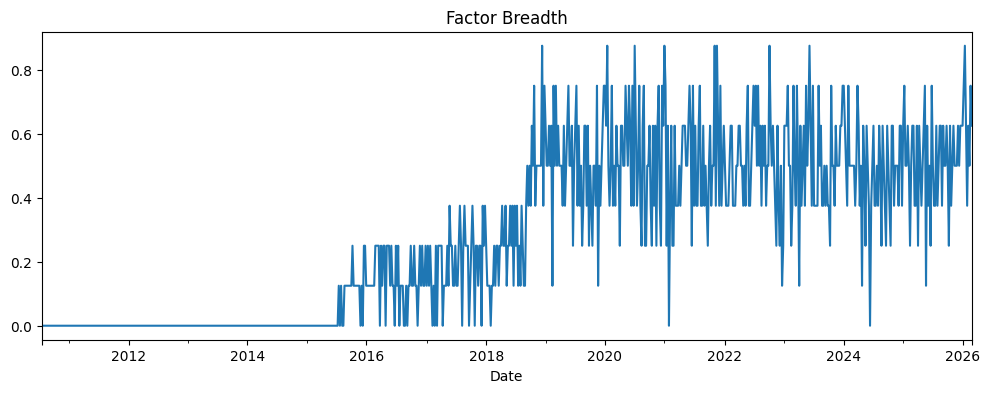

In [15]:
breadth = (factor_ret > 0).mean(axis=1)
breadth.plot(figsize=(12,4))
plt.title("Factor Breadth")
plt.show()

## Top Exposure ETF
PCA因子は
$$R=WF$$
$R$: ETF return
$F$: factor
$W$: loadings

各因子で $|W_{i,k}|$ が大きいETF

In [16]:
def label_factors(loadings_by_t, top_n=5):
    latest_t = list(loadings_by_t.keys())[-1]
    L = loadings_by_t[latest_t]
    labels = {}
    for f in L.columns:
        top = L[f].abs().sort_values(ascending=False).head(top_n)
        labels[f] = list(top.index)
    return labels
labels = label_factors(loadings_by_t)
labels

{'F1': ['BOTZ', 'AIQ', 'DRIV', 'MILN', 'FINX'],
 'F2': ['RNRG', 'CTEC', 'BITS', 'HYDR', 'BKCH'],
 'F3': ['BITS', 'BKCH', 'HYDR', 'CTEC', 'SOCL'],
 'F4': ['SHLD', 'PAVE', 'AQWA', 'SOCL', 'CTEC'],
 'F5': ['SHLD', 'SOCL', 'PAVE', 'AQWA', 'HERO'],
 'F6': ['AGNG', 'LIT', 'GNOM', 'DRIV', 'HEAL'],
 'F7': ['BUG', 'CLOU', 'AGNG', 'KROP', 'CTEC'],
 'F8': ['DTCR', 'KROP', 'GNOM', 'HERO', 'RNRG']}

## クラスタリング
loadingsをクラスタリング、ETFテーマごとまとまる

In [17]:
from sklearn.cluster import KMeans
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(L)
cluster_df = L.copy()
cluster_df["cluster"] = clusters
cluster_df.sort_values("cluster")

,F1,F2,F3,F4,F5,F6,F7,F8,cluster
Ticker,,,,,,,,,
AGNG,0.194805,0.128775,-0.166457,-0.050887,-0.164398,-0.420867,0.277149,0.023451,0
HEAL,0.215081,-0.064626,-0.071934,-0.138156,0.093424,-0.309025,0.095607,0.170294,0
GNOM,0.205783,0.053512,-0.055039,-0.165101,-0.005669,-0.347017,0.049763,0.215807,0
PAVE,0.197753,0.081998,0.011302,0.385453,-0.334468,0.216303,0.081436,0.063093,1
MILN,0.227830,-0.185529,-0.120316,0.018215,-0.122142,0.028859,0.008427,0.059893,1
KROP,0.185691,0.157279,-0.024660,0.156645,-0.078068,0.085380,0.274753,0.558824,1
HERO,0.203021,-0.052269,-0.151084,-0.133503,0.296881,-0.015058,0.233159,-0.203744,1
SNSR,0.226836,-0.000268,-0.084730,0.116944,-0.141530,0.206481,-0.034225,-0.114975,1
EBIZ,0.226648,-0.109932,-0.145960,-0.091573,0.144397,0.113641,0.158025,0.100345,1


## 均等因子ポートフォリオ

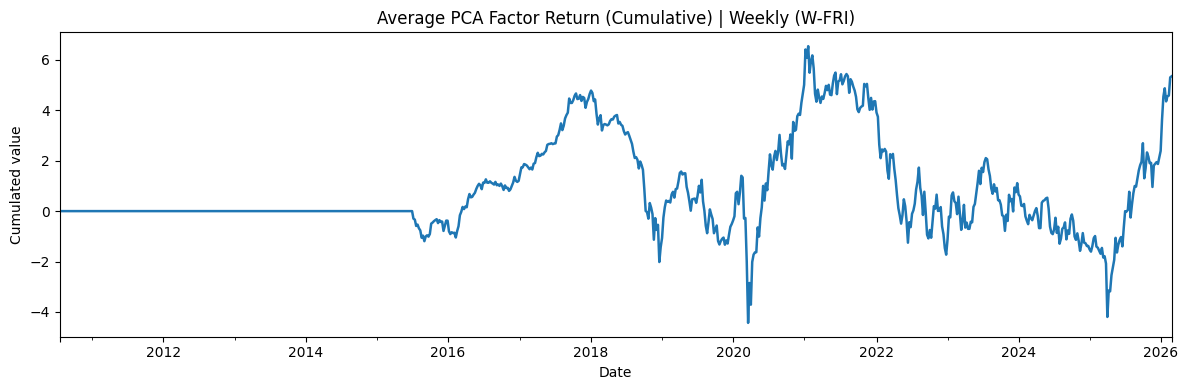

PCA eligibility count tail:


Date
2026-01-30    25
2026-02-06    25
2026-02-13    25
2026-02-20    25
2026-02-27    25
Freq: W-FRI, Name: eligible_count_pca, dtype: int64

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
((factor_ret.fillna(0).mean(axis=1)).cumsum()).plot(ax=ax, linewidth=1.8)
ax.set_title(f"Average PCA Factor Return (Cumulative) | {RUNTIME['frequency_label']}")
ax.set_ylabel('Cumulated value')
plt.tight_layout()
plt.show()
print('PCA eligibility count tail:')
display(elig_pca_count.tail())

In [19]:
def compute_factor_mom(factor_ret, lookbacks_periods, skip_periods, combine_weights_periods):
    # combine_weights を正規化（未正規化入力でも可）
    lookbacks = sorted(set(int(x) for x in lookbacks_periods))

    raw_w = {int(k): float(v) for k, v in combine_weights_periods.items() if int(k) in lookbacks}
    s = sum(raw_w.values())
    if s == 0:
        norm_w = {int(L): 1.0 / len(lookbacks) for L in lookbacks}
    else:
        norm_w = {int(L): raw_w.get(int(L), 0.0) / s for L in lookbacks}

    mom_parts = {}
    for L in lookbacks:
        L = int(L)
        # 短期lookbackは通常モメンタム、長期lookbackは skip を反映
        start_lag = 1
        if skip_periods > 0 and L > (skip_periods + 1):
            start_lag = skip_periods + 1

        lagged = [factor_ret.shift(j) for j in range(start_lag, L + 1)]
        mom_L = sum(lagged) if lagged else factor_ret * np.nan
        mom_parts[L] = mom_L

    mom_df = sum(norm_w[L] * mom_parts[L] for L in lookbacks)
    return mom_df, mom_parts, norm_w

factor_mom_raw, mom_parts, norm_cw = compute_factor_mom(
    factor_ret=factor_ret,
    lookbacks_periods=RUNTIME['lookbacks_periods'],
    skip_periods=RUNTIME['skip_periods'],
    combine_weights_periods=RUNTIME['combine_weights_periods'],
)

print('Runtime lookbacks(periods):', RUNTIME['lookbacks_periods'])
print('Runtime skip(periods):', RUNTIME['skip_periods'])
print('Normalized combine_weights(periods):', norm_cw)
print('Check sum(combine_weights_normalized)=', sum(norm_cw.values()))

Runtime lookbacks(periods): [4, 52]
Runtime skip(periods): 4
Normalized combine_weights(periods): {4: 0.5, 52: 0.5}
Check sum(combine_weights_normalized)= 1.0


## 指定PC除外

In [20]:

def resolve_excluded_factor_labels(exclude_pcs, factor_columns):
    labels = [c for c in factor_columns if isinstance(c, str) and c.startswith('F') and c[1:].isdigit()]
    valid_nums = {int(c[1:]) for c in labels}

    excluded = set()
    invalid = []
    for raw in (exclude_pcs or []):
        try:
            n = int(raw)
        except (TypeError, ValueError):
            invalid.append(raw)
            continue

        if n in valid_nums:
            excluded.add(f'F{n}')
        else:
            invalid.append(raw)

    if invalid:
        print(f"[WARN] invalid exclude_pcs ignored: {invalid}")

    return excluded


def apply_factor_exclusion(factor_mom, excluded_labels):
    factor_mom_ex = factor_mom.copy()
    cols = [c for c in excluded_labels if c in factor_mom_ex.columns]
    if cols:
        factor_mom_ex.loc[:, cols] = np.nan
    return factor_mom_ex

excluded_factor_labels = resolve_excluded_factor_labels(CONFIG.get('exclude_pcs', []), factor_mom_raw.columns)
factor_mom = apply_factor_exclusion(factor_mom_raw, excluded_factor_labels)

## 異なる期間のモメンタム加重平均
mom_parts（lookbackごとのモメンタム）
norm_cw（合成ウェイト）
factor_mom（最終モメンタム）

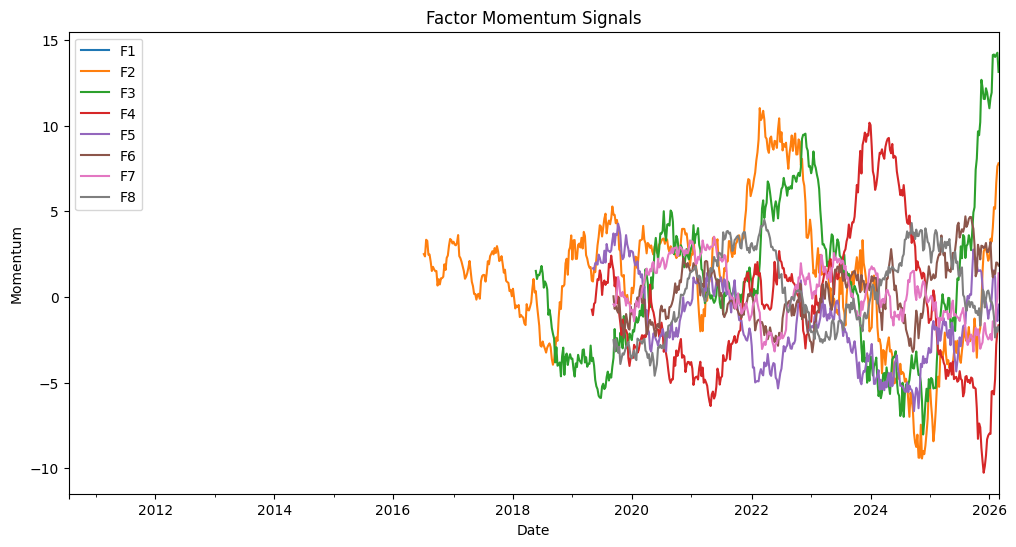

In [21]:
fig, ax = plt.subplots(figsize=(12,6))
factor_mom.plot(ax=ax)
ax.set_title("Factor Momentum Signals")
ax.set_ylabel("Momentum")
plt.show()

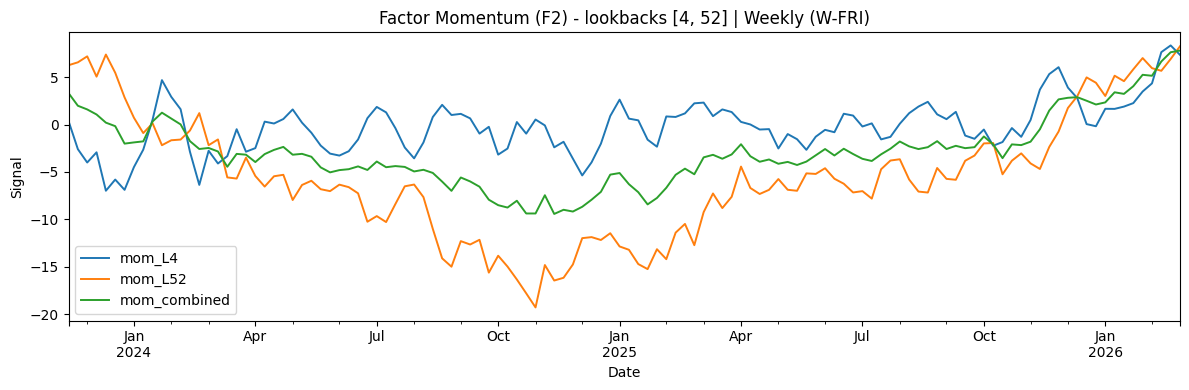

In [22]:
lookbacks_sorted = sorted(mom_parts.keys())
sample_factor = 'F2'
plot_dict = {f"mom_L{lb}": mom_parts[lb][sample_factor] for lb in lookbacks_sorted}
plot_dict['mom_combined'] = factor_mom[sample_factor]
plot_df = pd.DataFrame(plot_dict).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
plot_df.tail(120).plot(ax=ax, linewidth=1.4)
ax.set_title(f"Factor Momentum ({sample_factor}) - lookbacks {lookbacks_sorted} | {RUNTIME['frequency_label']}")
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

## Factor Momentum シグナル（factor_mom）を「因子ポートフォリオのウェイト」へ変換する関数
1. top_m: 上位m個
2. rank: モメンタム順位で重みつけ
3. sign: モメンタム符号が正のもの

In [23]:
def normalize_long_only(w):
    w = w.clip(lower=0.0)
    total = w.sum()
    if total > 0:
        return w / total
    return w * 0.0


def normalize_ls(w):
    gross = w.abs().sum()
    if gross > 0:
        return w / gross
    return w * 0.0

def allocate_factor_weights(mom_t, method='top_m', top_m=3, long_only=True):
    x = mom_t.dropna().copy()
    if len(x) == 0:
        return pd.Series(index=mom_t.index, data=0.0)

    if method == 'top_m':
        winners = x.nlargest(min(top_m, len(x)))
        w = pd.Series(0.0, index=x.index)
        if long_only:
            winners = winners[winners > 0]
            if len(winners) > 0:
                w.loc[winners.index] = 1.0 / len(winners)
        else:
            w.loc[winners.index] = 1.0 / len(winners)

    elif method == 'rank':
        r = x.rank(method='average', ascending=True)
        w = r - r.min()
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w - w.mean())

    elif method == 'sign':
        w = np.sign(x)
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w)

    else:
        raise ValueError(f'Unknown factor_weighting method: {method}')

    # full factor indexへ戻す
    out = pd.Series(0.0, index=mom_t.index)
    out.loc[w.index] = w.values

    if long_only:
        out = normalize_long_only(out)
    else:
        out = normalize_ls(out)

    return out

# factor_weighting 3方式の比較（同一期）
latest_t = factor_mom.dropna(how='all').index[-1]
w_top = allocate_factor_weights(factor_mom.loc[latest_t], method='top_m', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
w_rank = allocate_factor_weights(factor_mom.loc[latest_t], method='rank', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
w_sign = allocate_factor_weights(factor_mom.loc[latest_t], method='sign', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])

print(f'Factor allocation comparison at {latest_t.date()}')
display(pd.DataFrame({'top_m': w_top, 'rank': w_rank, 'sign': w_sign}).T)

Factor allocation comparison at 2026-02-27


,F1,F2,F3,F4,F5,F6,F7,F8
top_m,0.0,0.333333,0.333333,0.000000,0.000000,0.333333,0.000000,0.0
rank,0.0,0.238095,0.285714,0.047619,0.095238,0.190476,0.142857,0.0
sign,0.0,0.250000,0.250000,0.000000,0.000000,0.250000,0.250000,0.0


## PCA因子ポート（因子ウェイト）を「実際に買えるETFのウェイト」に変換する写像
$$w_t^{ETF} \propto W_t w_t^{factor}$$
右辺を実行し合計１になるよう圧縮

### regression
過去reression期間を用いてETFごとに
$$r_{i,\tau}=\alpha_i+\beta_i f_\tau + \epsilon_{i,\tau}$$
を最小二乗法で推定。
$$w_t^{ETF} \propto \beta_i w_t^{factor}$$
既知因子を加えて回帰する。

In [24]:
def apply_weight_cap(w, cap=None):
    if cap is None:
        return w
    w = w.clip(upper=cap)
    if (w >= 0).all():
        return normalize_long_only(w)
    return normalize_ls(w)

## 7) S2-L: mapping(loadings) + backtest + plots

def map_loadings_to_etf(loadings_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index

    fac = loadings_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = loadings_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w

all_tickers = ret_p.columns.tolist()
eligibility_mask_by_t = elig_pca_count.attrs['eligibility_mask_by_t']

weights_s2l_dict = {}
skipped_s2l = 0

for t in sorted(loadings_by_t.keys()):
    if t not in factor_mom.index:
        continue
    mom_t = factor_mom.loc[t]
    if mom_t.isna().all():
        skipped_s2l += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    elig_t = eligibility_mask_by_t.get(t, pd.Series(False, index=all_tickers)).reindex(all_tickers).fillna(False)
    w_etf_t = map_loadings_to_etf(loadings_by_t[t], w_factor_t, elig_t, cap=CONFIG['weight_cap'])

    if np.isclose(w_etf_t.sum(), 0.0):
        skipped_s2l += 1
        continue

    weights_s2l_dict[t] = w_etf_t

weights_s2l = pd.DataFrame.from_dict(weights_s2l_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()


In [25]:

def compute_turnover(w_t, w_prev):
    return 0.5 * np.abs(w_t - w_prev).sum()


def calc_drawdown(equity):
    peak = equity.cummax()
    return equity / peak - 1.0


def next_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])
    nxt = int(pos) + 1
    if nxt >= len(idx):
        return None
    return idx[nxt]


In [26]:

def run_backtest(weights_by_t, ret_p, cost_bps):
    if weights_by_t.empty:
        idx = pd.DatetimeIndex([], name='period')
        empty = pd.Series(index=idx, dtype=float)
        return empty.copy(), empty.copy(), empty.copy(), empty.copy(), empty.copy()

    weights_by_t = weights_by_t.sort_index().fillna(0.0)
    tickers = list(weights_by_t.columns)

    decision_periods = []
    applied_periods = []
    gross_vals = []
    net_vals = []
    turn_vals = []

    w_prev = pd.Series(0.0, index=tickers)

    for t, w_t in weights_by_t.iterrows():
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue

        r_next = ret_p.loc[apply_t].reindex(tickers).fillna(0.0)
        w_t = w_t.reindex(tickers).fillna(0.0)

        turnover = compute_turnover(w_t, w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (cost_bps / 10000.0)

        decision_periods.append(t)
        applied_periods.append(apply_t)
        gross_vals.append(gross)
        net_vals.append(net)
        turn_vals.append(turnover)

        w_prev = w_t

    idx = pd.DatetimeIndex(applied_periods, name='period')
    gross_s = pd.Series(gross_vals, index=idx, name='gross')
    net_s = pd.Series(net_vals, index=idx, name='net')
    turnover_s = pd.Series(turn_vals, index=idx, name='turnover')

    equity = (1.0 + net_s).cumprod().rename('equity')
    dd = calc_drawdown(equity).rename('drawdown')

    decision_idx = pd.DatetimeIndex(decision_periods, name='decision_period')
    for s in (gross_s, net_s, turnover_s, equity, dd):
        s.attrs['decision_periods'] = decision_idx

    return gross_s, net_s, turnover_s, equity, dd


def build_eqw(eligibility_by_t, ret_p, cost_bps):
    tickers = list(eligibility_by_t.columns)
    rows = {}
    for t, elig in eligibility_by_t.sort_index().iterrows():
        elig = elig.reindex(tickers).fillna(False)
        w = pd.Series(0.0, index=tickers)
        n = int(elig.sum())
        if n > 0:
            w.loc[elig.index[elig.values]] = 1.0 / n
        rows[t] = w

    weights_eqw = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=tickers).fillna(0.0)
    _, eqw_net, eqw_turnover, eqw_equity, eqw_dd = run_backtest(weights_eqw, ret_p, cost_bps)

    return eqw_net, eqw_turnover, eqw_equity, eqw_dd


def plot_equity_dd(equity_map, dd_map, title_prefix='Strategy Comparison'):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for name, s in equity_map.items():
        axes[0].plot(s.index, s.values, label=name, linewidth=2)
    axes[0].set_title(f'{title_prefix} - Equity Curve')
    axes[0].set_ylabel('Equity (start=1)')
    axes[0].legend()

    for name, s in dd_map.items():
        axes[1].plot(s.index, s.values, label=name, linewidth=1.8)
    axes[1].set_title(f'{title_prefix} - Drawdown Curve')
    axes[1].set_ylabel('Drawdown')
    axes[1].set_xlabel(f"Period ({RUNTIME['rule']})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

S2-L decision periods: 474 (skipped=82)
S2-L net return periods: 473


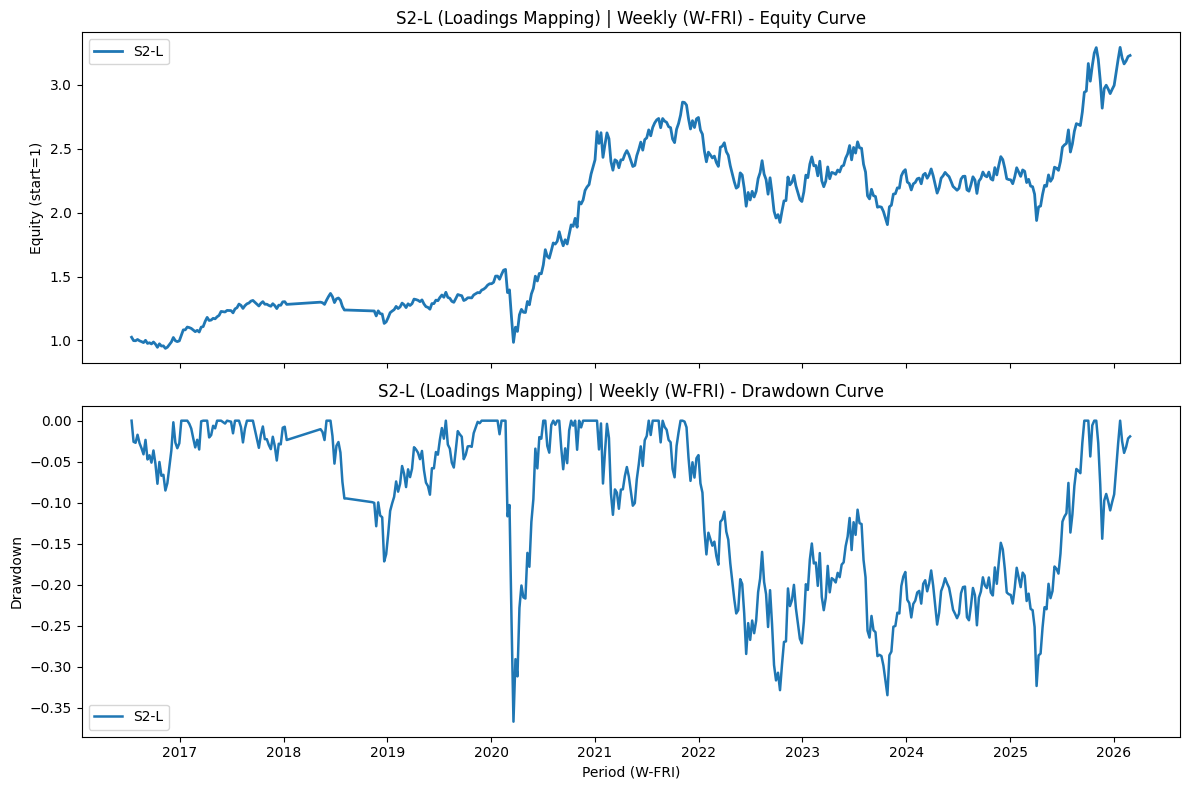

In [27]:

gross_s2l, net_s2l, turnover_s2l, equity_s2l, dd_s2l = run_backtest(weights_s2l, ret_p, CONFIG['cost_bps'])

print(f'S2-L decision periods: {len(weights_s2l)} (skipped={skipped_s2l})')
print(f'S2-L net return periods: {len(net_s2l)}')

plot_equity_dd(
    equity_map={'S2-L': equity_s2l},
    dd_map={'S2-L': dd_s2l},
    title_prefix=f"S2-L (Loadings Mapping) | {RUNTIME['frequency_label']}"
)


S2-R decision periods: 287 (skipped=528)
S2-R net return periods: 286


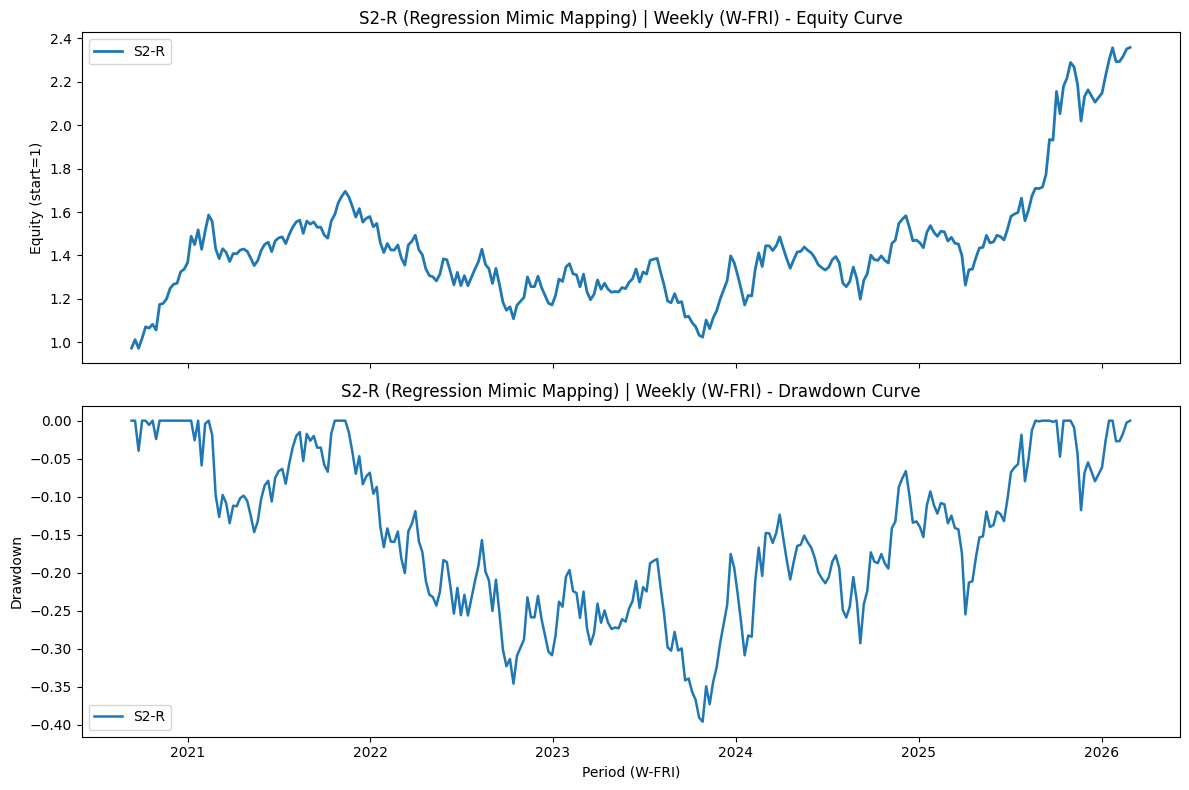

,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.039803,0.000000,0.000000,0.0,0.0,0.015722,0.0,0.0,0.0,0.195231,...,0.0,0.006904,0.210388,0.0,0.001860,0.097961,0.023907,0.026453,0.0,0.0
2026-02-06,0.000000,0.006496,0.028839,0.0,0.0,0.043997,0.0,0.0,0.0,0.133432,...,0.0,0.114815,0.134689,0.0,0.104897,0.044433,0.000000,0.076171,0.0,0.0
2026-02-13,0.000000,0.006125,0.029229,0.0,0.0,0.044406,0.0,0.0,0.0,0.129003,...,0.0,0.117516,0.134963,0.0,0.105002,0.042680,0.000000,0.078240,0.0,0.0
2026-02-20,0.000000,0.005661,0.028982,0.0,0.0,0.044677,0.0,0.0,0.0,0.129080,...,0.0,0.117698,0.133101,0.0,0.106478,0.041863,0.000000,0.078259,0.0,0.0
2026-02-27,0.000000,0.005665,0.028986,0.0,0.0,0.044675,0.0,0.0,0.0,0.129006,...,0.0,0.117706,0.133144,0.0,0.106502,0.041827,0.000000,0.078252,0.0,0.0


In [28]:
## 8) S2-R: mapping(regression mimic) + backtest + plots

def estimate_regression_betas(ret_p, factor_ret, t, window_periods=60, min_obs=24):
    if t not in ret_p.index:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    pos = ret_p.index.get_loc(t)
    if pos < window_periods - 1:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    win_idx = ret_p.index[pos - window_periods + 1 : pos + 1]
    X_all = factor_ret.reindex(win_idx)

    valid_factor_cols = [c for c in factor_ret.columns if pd.notna(factor_ret.loc[t, c])]
    if len(valid_factor_cols) == 0:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    X_all = X_all[valid_factor_cols]

    beta_rows = {}
    for tk in ret_p.columns:
        if pd.isna(ret_p.loc[t, tk]):
            continue
        y = ret_p.loc[win_idx, tk]
        reg_df = pd.concat([y.rename('y'), X_all], axis=1).dropna()

        need_obs = max(min_obs, len(valid_factor_cols) + 1)
        if len(reg_df) < need_obs:
            continue

        yv = reg_df['y'].values
        xv = reg_df[valid_factor_cols].values
        xv = np.column_stack([np.ones(len(xv)), xv])

        coef = np.linalg.lstsq(xv, yv, rcond=None)[0]
        beta_rows[tk] = coef[1:]

    if not beta_rows:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    beta_mat = pd.DataFrame.from_dict(beta_rows, orient='index', columns=valid_factor_cols)
    elig = pd.Series(False, index=ret_p.columns)
    elig.loc[beta_mat.index] = True

    return beta_mat, elig


def map_regression_to_etf(beta_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index
    if beta_t.empty:
        return pd.Series(0.0, index=all_assets)

    fac = beta_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = beta_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w


weights_s2r_dict = {}
elig_reg_count = pd.Series(index=ret_p.index, dtype=float)
skipped_s2r = 0

for t in sorted(factor_mom.index):
    if t not in ret_p.index:
        continue

    mom_t = factor_mom.loc[t]
    if mom_t.isna().all():
        skipped_s2r += 1
        continue

    beta_t, elig_t = estimate_regression_betas(
        ret_p=ret_p,
        factor_ret=factor_ret,
        t=t,
        window_periods=RUNTIME['reg_window'],
        min_obs=RUNTIME['min_obs'],
    )

    elig_reg_count.loc[t] = int(elig_t.sum())
    if beta_t.empty:
        skipped_s2r += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    w_etf_t = map_regression_to_etf(beta_t, w_factor_t, elig_t, cap=CONFIG['weight_cap'])
    if np.isclose(w_etf_t.sum(), 0.0):
        skipped_s2r += 1
        continue

    weights_s2r_dict[t] = w_etf_t

weights_s2r = pd.DataFrame.from_dict(weights_s2r_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()
elig_reg_count = elig_reg_count.fillna(0).astype(int).rename('eligible_count_reg')

gross_s2r, net_s2r, turnover_s2r, equity_s2r, dd_s2r = run_backtest(weights_s2r, ret_p, CONFIG['cost_bps'])

print(f'S2-R decision periods: {len(weights_s2r)} (skipped={skipped_s2r})')
print(f'S2-R net return periods: {len(net_s2r)}')

plot_equity_dd(
    equity_map={'S2-R': equity_s2r},
    dd_map={'S2-R': dd_s2r},
    title_prefix=f"S2-R (Regression Mimic Mapping) | {RUNTIME['frequency_label']}"
)

weights_s2r.tail()

Common comparison window: 2020-09-11 -> 2026-02-27 (286 periods)


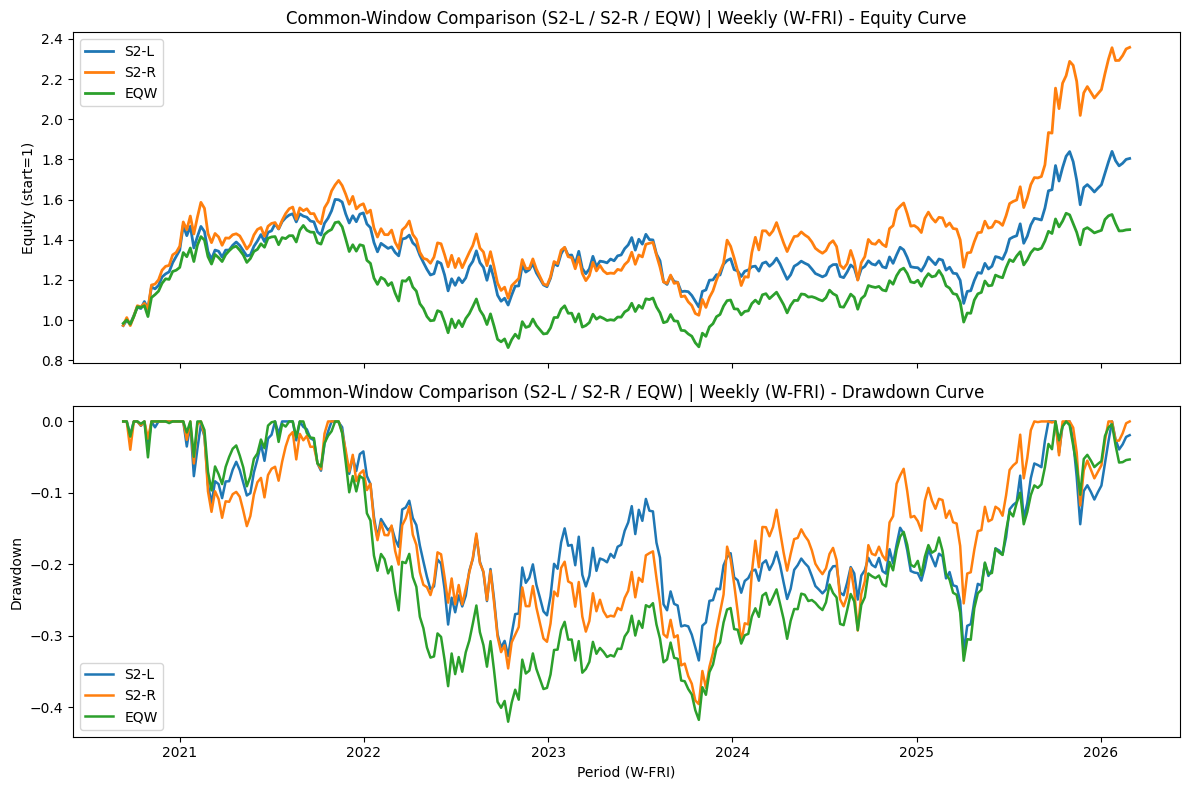

In [29]:
## 9) Compare (S2-L vs S2-R vs EQW) equity & drawdown

# EQW eligibility: PCAの時点tで投資候補になったETFを採用
eligibility_eqw = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)
elig_eqw_count = eligibility_eqw.sum(axis=1).rename('eligible_count_eqw')

eqw_net, eqw_turnover, eqw_equity, eqw_dd = build_eqw(eligibility_eqw, ret_p, CONFIG['cost_bps'])

common_idx = net_s2l.index.intersection(net_s2r.index).intersection(eqw_net.index)
if len(common_idx) == 0:
    raise ValueError('No common comparison period among S2-L, S2-R, EQW.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common comparison window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

net_s2l_c = net_s2l.reindex(common_idx)
net_s2r_c = net_s2r.reindex(common_idx)
eqw_net_c = eqw_net.reindex(common_idx)

turn_s2l_c = turnover_s2l.reindex(common_idx)
turn_s2r_c = turnover_s2r.reindex(common_idx)
eqw_turn_c = eqw_turnover.reindex(common_idx)

equity_s2l_c = (1 + net_s2l_c).cumprod()
equity_s2r_c = (1 + net_s2r_c).cumprod()
eqw_equity_c = (1 + eqw_net_c).cumprod()

dd_s2l_c = calc_drawdown(equity_s2l_c)
dd_s2r_c = calc_drawdown(equity_s2r_c)
eqw_dd_c = calc_drawdown(eqw_equity_c)

plot_equity_dd(
    equity_map={'S2-L': equity_s2l_c, 'S2-R': equity_s2r_c, 'EQW': eqw_equity_c},
    dd_map={'S2-L': dd_s2l_c, 'S2-R': dd_s2r_c, 'EQW': eqw_dd_c},
    title_prefix=f"Common-Window Comparison (S2-L / S2-R / EQW) | {RUNTIME['frequency_label']}"
)

In [30]:


def calc_metrics(net_ret, turnover, periods_per_year):
    r = net_ret.dropna()
    if len(r) == 0:
        return pd.Series({'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan, 'MDD': np.nan, 'Turnover': np.nan, 'Hit': np.nan})

    years = len(r) / float(periods_per_year)
    cagr = (1.0 + r).prod() ** (1.0 / years) - 1.0 if years > 0 else np.nan
    vol = r.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = (r.mean() / r.std(ddof=0) * np.sqrt(periods_per_year)) if r.std(ddof=0) > 0 else np.nan

    equity = (1.0 + r).cumprod()
    mdd = calc_drawdown(equity).min()
    to = turnover.reindex(r.index).mean()
    hit = (r > 0).mean()

    return pd.Series({'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MDD': mdd, 'Turnover': to, 'Hit': hit})



## 10) Metrics table (CAGR/Vol/Sharpe/MDD/Turnover/Hit)

metrics = pd.DataFrame({
    'S2-L': calc_metrics(net_s2l_c, turn_s2l_c, RUNTIME['periods_per_year']),
    'S2-R': calc_metrics(net_s2r_c, turn_s2r_c, RUNTIME['periods_per_year']),
    'EQW': calc_metrics(eqw_net_c, eqw_turn_c, RUNTIME['periods_per_year']),
}).T

print('Performance metrics on common window:')
display(metrics)

# basic sanity checks
assert np.isfinite(metrics[['CAGR','Vol','Sharpe','MDD','Turnover','Hit']].values).all(), 'Metrics contain NaN/inf.'
print('Metrics sanity check passed.')

Performance metrics on common window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
S2-L,0.113316,0.225876,0.588568,-0.334720,0.122119,0.520979
S2-R,0.168788,0.260140,0.729698,-0.395964,0.103925,0.538462
EQW,0.069945,0.222041,0.415403,-0.420529,0.002737,0.517483


Metrics sanity check passed.


## 1) 参照論文URLと実装要点メモ

- Factor Momentum Everywhere (AQR WP)  
  <https://www.aqr.com/Insights/Research/Working-Paper/Factor-Momentum-Everywhere>
- Factor Momentum (RFS, 2023)  
  <https://academic.oup.com/rfs/article-abstract/36/8/3034/6988043>
- Factor Momentum and the Momentum Factor (NBER WP 25551)  
  <https://www.nber.org/system/files/working_papers/w25551/w25551.pdf>

**実装要点（本Notebook）**
- 因子は Rolling PCA（実効窓: `rebalance` に応じて自動換算）で各期再推定。
- 因子モメンタムは `lookback=1` と `lookback=12(12-1)` を月次意味で指定し、周波数に応じて期間換算。
- 因子配分は `top_m` をデフォルト実装（`rank`,`sign` も関数で切替可）。
- ETF写像は S2-L（loadings）と S2-R（regression mimic）を両方バックテスト。
- 期末で重み決定し、次期リターンへ適用（`w_t -> r_{t+1}`）。
- コスト控除は `turnover = 0.5 * sum(|w_t - w_{t-1}|)`、`net = gross - turnover * (cost_bps/10000)`。
- 比較は S2-L / S2-R / EQW を共通期間で実施。

## 11) Sign-Aware ETF mapping（因子符号ではなくETF予測符号で判断）

因子選択は `|factor_mom|` で行い、写像時は符号付きモメンタムを使って `ETF期待リターン` を推定します。


In [31]:
def build_signed_factor_signal(mom_t, top_m=3, select_by_abs=True):
    """
    因子選択は |mom| ベース（既定）で行い、選択後は符号付き mom を保持。
    返すシグナルは sum(abs(signal)) で正規化。
    """
    out = pd.Series(0.0, index=mom_t.index, dtype=float)
    x = mom_t.dropna().copy()
    if len(x) == 0:
        return out

    top_m = max(0, int(top_m))
    if top_m == 0:
        return out

    k = min(top_m, len(x))
    if select_by_abs:
        picked_idx = x.abs().nlargest(k).index
    else:
        picked_idx = x.nlargest(k).index

    out.loc[picked_idx] = x.loc[picked_idx].values

    scale = out.abs().sum()
    if scale > 0:
        out = out / scale
    return out


def predict_etf_returns(exposure_t, factor_signal_t, elig_mask_t):
    """r_hat_etf = exposure @ signed_factor_signal"""
    all_assets = elig_mask_t.index
    if exposure_t is None or exposure_t.empty:
        return pd.Series(0.0, index=all_assets)

    fac = exposure_t.columns.intersection(factor_signal_t.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    signal_vec = factor_signal_t.reindex(fac).fillna(0.0)
    r_hat_raw = exposure_t[fac].dot(signal_vec)

    r_hat = pd.Series(0.0, index=all_assets, dtype=float)
    r_hat.loc[r_hat_raw.index] = r_hat_raw.values
    r_hat.loc[~elig_mask_t] = 0.0
    return r_hat.fillna(0.0)


def allocate_etf_weights_from_prediction(r_hat_t, mode='proportional', top_k=5, long_only=True):
    """ETF期待リターンから最終ウェイトを構築。"""
    out = pd.Series(0.0, index=r_hat_t.index, dtype=float)
    x = r_hat_t.fillna(0.0).copy()

    if long_only:
        pos = x[x > 0]
        if len(pos) == 0:
            return out

        if mode == 'proportional':
            out.loc[pos.index] = pos.values
            return normalize_long_only(out)

        if mode == 'topk_equal':
            k = max(1, int(top_k))
            winners = pos.nlargest(min(k, len(pos)))
            out.loc[winners.index] = 1.0 / len(winners)
            return out

        raise ValueError(f'Unknown etf_weight_mode: {mode}')

    # long_only=False を使う場合のフォールバック
    if mode == 'topk_equal':
        k = max(1, int(top_k))
        winners = x.abs().nlargest(min(k, len(x)))
        out.loc[winners.index] = np.sign(x.loc[winners.index])
        return normalize_ls(out)

    return normalize_ls(x)


def run_sign_aware_mapping(decision_times, factor_mom, all_tickers, get_exposure_elig, config):
    """
    共通ドライバ: S2-L-SA / S2-R-SA の両方で利用。
    get_exposure_elig(t) -> (exposure_df[ETF x factor], eligibility_series[ETF])
    """
    weights_dict = {}
    signal_by_t = {}
    pred_by_t = {}
    exposure_by_t = {}
    skipped = 0

    for t in sorted(decision_times):
        if t not in factor_mom.index:
            continue

        mom_t = factor_mom.loc[t]
        if mom_t.isna().all():
            skipped += 1
            continue

        factor_signal_t = build_signed_factor_signal(
            mom_t=mom_t,
            top_m=config['top_m_factors'],
            select_by_abs=config.get('factor_select_by_abs_mom', True),
        )
        if np.isclose(factor_signal_t.abs().sum(), 0.0):
            skipped += 1
            continue

        exposure_t, elig_t = get_exposure_elig(t)
        if exposure_t is None or len(exposure_t) == 0:
            skipped += 1
            continue

        exposure_t = exposure_t.copy()
        elig_t = elig_t.reindex(all_tickers).fillna(False).astype(bool)

        r_hat_t = predict_etf_returns(exposure_t, factor_signal_t, elig_t)
        w_t = allocate_etf_weights_from_prediction(
            r_hat_t=r_hat_t,
            mode=config.get('etf_weight_mode', 'proportional'),
            top_k=config.get('etf_top_k', 5),
            long_only=config.get('long_only', True),
        )
        w_t = apply_weight_cap(w_t, cap=config.get('weight_cap'))

        if np.isclose(w_t.sum(), 0.0):
            skipped += 1
            continue

        weights_dict[t] = w_t
        signal_by_t[t] = factor_signal_t.copy()
        pred_by_t[t] = r_hat_t.copy()

        exp_full = pd.DataFrame(0.0, index=all_tickers, columns=factor_signal_t.index)
        fac = exposure_t.columns.intersection(factor_signal_t.index)
        if len(fac) > 0:
            exp_full.loc[exposure_t.index, fac] = exposure_t.loc[:, fac].values
        exp_full.loc[~elig_t, :] = 0.0
        exposure_by_t[t] = exp_full

    weights = pd.DataFrame.from_dict(weights_dict, orient='index')
    weights = weights.reindex(columns=all_tickers).fillna(0.0).sort_index()

    diagnostics = {
        'signal_by_t': signal_by_t,
        'pred_by_t': pred_by_t,
        'exposure_by_t': exposure_by_t,
    }

    return weights, skipped, diagnostics


## 16) 正則化Rolling Exposure推定（Ridge/Lasso/NNLS）


In [32]:
def estimate_regression_exposure_regularized(
    ret_p,
    factor_ret,
    t,
    window_periods,
    min_obs,
    model='ridge',
    ridge_alpha=5.0,
    lasso_alpha=0.001,
    lasso_max_iter=10000,
    standardize_x=True,
    nnls_fit_intercept=True,
):
    if t not in ret_p.index:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    pos = ret_p.index.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])

    if pos < window_periods - 1:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    win_idx = ret_p.index[pos - window_periods + 1 : pos + 1]

    valid_factor_cols = [c for c in factor_ret.columns if pd.notna(factor_ret.loc[t, c])]
    if len(valid_factor_cols) == 0:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    X_all = factor_ret.reindex(win_idx)[valid_factor_cols]
    model_l = str(model).lower()

    beta_rows = {}

    for tk in ret_p.columns:
        if pd.isna(ret_p.loc[t, tk]):
            continue

        y = ret_p.loc[win_idx, tk]
        reg_df = pd.concat([y.rename('y'), X_all], axis=1).dropna()

        need_obs = max(min_obs, len(valid_factor_cols) + 1)
        if len(reg_df) < need_obs:
            continue

        yv = reg_df['y'].values.astype(float)
        X = reg_df[valid_factor_cols].values.astype(float)

        if standardize_x:
            mu = X.mean(axis=0)
            sd = X.std(axis=0, ddof=0)
            sd = np.where(sd <= 0, 1.0, sd)
            X_std = (X - mu) / sd
        else:
            mu = np.zeros(X.shape[1])
            sd = np.ones(X.shape[1])
            X_std = X

        if model_l == 'ridge':
            reg = Ridge(alpha=float(ridge_alpha), fit_intercept=True, random_state=42)
            reg.fit(X_std, yv)
            coef_std = reg.coef_.astype(float)
            intercept_std = float(reg.intercept_)

        elif model_l == 'lasso':
            reg = Lasso(alpha=float(lasso_alpha), fit_intercept=True, max_iter=int(lasso_max_iter), random_state=42)
            reg.fit(X_std, yv)
            coef_std = reg.coef_.astype(float)
            intercept_std = float(reg.intercept_)

        elif model_l == 'nnls':
            if nnls_fit_intercept:
                y_mean = float(yv.mean())
                coef_std, _ = nnls(X_std, yv - y_mean)
                intercept_std = y_mean
            else:
                coef_std, _ = nnls(X_std, yv)
                intercept_std = 0.0
            coef_std = coef_std.astype(float)

        else:
            raise ValueError(f'Unknown regularized exposure model: {model}')

        if standardize_x:
            coef = coef_std / sd
            intercept = float(intercept_std - np.dot(mu, coef))
        else:
            coef = coef_std
            intercept = intercept_std

        _ = intercept  # 明示: 現在は写像に係数のみ使用
        beta_rows[tk] = coef

    if not beta_rows:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    beta_mat = pd.DataFrame.from_dict(beta_rows, orient='index', columns=valid_factor_cols).astype(float)

    elig = pd.Series(False, index=ret_p.columns)
    elig.loc[beta_mat.index] = True

    return beta_mat, elig


def get_exposure_elig_s2r_regularized_factory(model):
    model_l = str(model).lower()

    def _getter(t):
        return estimate_regression_exposure_regularized(
            ret_p=ret_p,
            factor_ret=factor_ret,
            t=t,
            window_periods=RUNTIME['reg_window'],
            min_obs=RUNTIME['min_obs'],
            model=model_l,
            ridge_alpha=CONFIG.get('ridge_alpha', 5.0),
            lasso_alpha=CONFIG.get('lasso_alpha', 0.001),
            lasso_max_iter=CONFIG.get('lasso_max_iter', 10000),
            standardize_x=CONFIG.get('exposure_standardize_x', True),
            nnls_fit_intercept=CONFIG.get('nnls_fit_intercept', True),
        )

    return _getter


## 12) Sign-Aware戦略の実行（S2-L-SA / S2-R-SA）


S2-L-SA decision periods: 504 (skipped=52)
S2-R-SA decision periods: 287 (skipped=528)
etf_weight_mode=proportional | etf_top_k=5


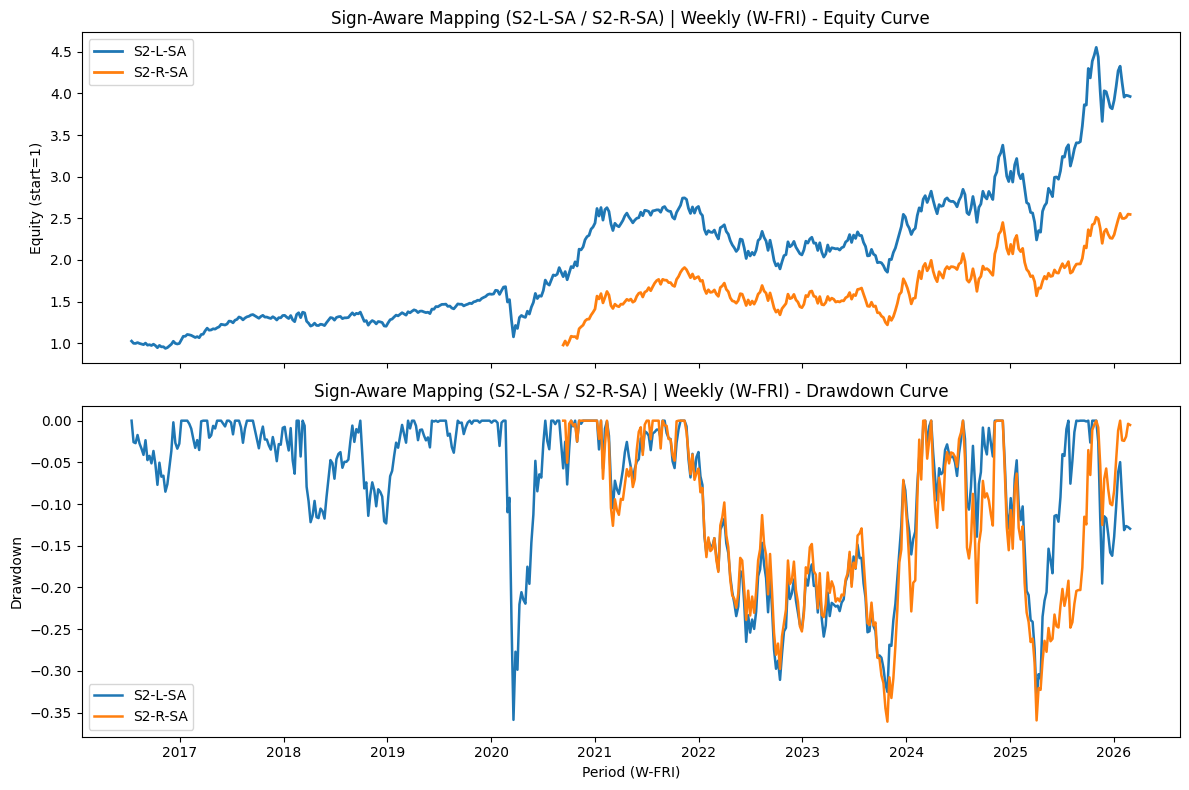

,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.0,0.0,0.000000,0.160679,0.157003,0.0,0.0,0.0,0.0,0.187344,...,0.0,0.002833,0.062159,0.0,0.000000,0.148411,0.000000,0.0,0.0,0.0
2026-02-06,0.0,0.0,0.000000,0.170448,0.166632,0.0,0.0,0.0,0.0,0.181633,...,0.0,0.006702,0.063800,0.0,0.000000,0.136626,0.000000,0.0,0.0,0.0
2026-02-13,0.0,0.0,0.000000,0.151900,0.150319,0.0,0.0,0.0,0.0,0.175969,...,0.0,0.026990,0.062231,0.0,0.012802,0.138834,0.000000,0.0,0.0,0.0
2026-02-20,0.0,0.0,0.009965,0.152716,0.147348,0.0,0.0,0.0,0.0,0.161602,...,0.0,0.000000,0.054510,0.0,0.025465,0.142710,0.012439,0.0,0.0,0.0
2026-02-27,0.0,0.0,0.000000,0.144851,0.143936,0.0,0.0,0.0,0.0,0.168594,...,0.0,0.030532,0.079713,0.0,0.034124,0.121880,0.000000,0.0,0.0,0.0


,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.051736,0.0,0.019057,0.0,0.0,0.002319,0.0,0.0,0.0,0.227443,...,0.0,0.021764,0.047419,0.0,0.029131,0.141043,0.000000,0.002438,0.0,0.0
2026-02-06,0.048489,0.0,0.019733,0.0,0.0,0.003752,0.0,0.0,0.0,0.225076,...,0.0,0.026420,0.056230,0.0,0.033031,0.134762,0.000000,0.005285,0.0,0.0
2026-02-13,0.042578,0.0,0.023105,0.0,0.0,0.009988,0.0,0.0,0.0,0.205387,...,0.0,0.036774,0.075961,0.0,0.046868,0.125398,0.000812,0.016727,0.0,0.0
2026-02-20,0.021165,0.0,0.023542,0.0,0.0,0.018757,0.0,0.0,0.0,0.203142,...,0.0,0.030606,0.083523,0.0,0.060637,0.116045,0.014161,0.027869,0.0,0.0
2026-02-27,0.024376,0.0,0.026335,0.0,0.0,0.018454,0.0,0.0,0.0,0.180672,...,0.0,0.060204,0.098822,0.0,0.069364,0.103383,0.017049,0.032688,0.0,0.0


In [33]:
def get_exposure_elig_s2l(t):
    exposure_t = loadings_by_t.get(t, pd.DataFrame())
    elig_t = eligibility_mask_by_t.get(t, pd.Series(False, index=all_tickers))
    return exposure_t, elig_t


def get_exposure_elig_s2r(t):
    beta_t, elig_t = estimate_regression_betas(
        ret_p=ret_p,
        factor_ret=factor_ret,
        t=t,
        window_periods=RUNTIME['reg_window'],
        min_obs=RUNTIME['min_obs'],
    )
    return beta_t, elig_t


if CONFIG.get('run_sign_aware', True):
    weights_s2l_sa, skipped_s2l_sa, diag_s2l_sa = run_sign_aware_mapping(
        decision_times=sorted(loadings_by_t.keys()),
        factor_mom=factor_mom,
        all_tickers=all_tickers,
        get_exposure_elig=get_exposure_elig_s2l,
        config=CONFIG,
    )

    weights_s2r_sa, skipped_s2r_sa, diag_s2r_sa = run_sign_aware_mapping(
        decision_times=sorted(factor_mom.index),
        factor_mom=factor_mom,
        all_tickers=all_tickers,
        get_exposure_elig=get_exposure_elig_s2r,
        config=CONFIG,
    )
else:
    weights_s2l_sa = pd.DataFrame(columns=all_tickers)
    weights_s2r_sa = pd.DataFrame(columns=all_tickers)
    skipped_s2l_sa = skipped_s2r_sa = 0
    diag_s2l_sa = {'signal_by_t': {}, 'pred_by_t': {}, 'exposure_by_t': {}}
    diag_s2r_sa = {'signal_by_t': {}, 'pred_by_t': {}, 'exposure_by_t': {}}

gross_s2l_sa, net_s2l_sa, turnover_s2l_sa, equity_s2l_sa, dd_s2l_sa = run_backtest(weights_s2l_sa, ret_p, CONFIG['cost_bps'])
gross_s2r_sa, net_s2r_sa, turnover_s2r_sa, equity_s2r_sa, dd_s2r_sa = run_backtest(weights_s2r_sa, ret_p, CONFIG['cost_bps'])

print(f"S2-L-SA decision periods: {len(weights_s2l_sa)} (skipped={skipped_s2l_sa})")
print(f"S2-R-SA decision periods: {len(weights_s2r_sa)} (skipped={skipped_s2r_sa})")
print(f"etf_weight_mode={CONFIG.get('etf_weight_mode')} | etf_top_k={CONFIG.get('etf_top_k')}")

plot_equity_dd(
    equity_map={'S2-L-SA': equity_s2l_sa, 'S2-R-SA': equity_s2r_sa},
    dd_map={'S2-L-SA': dd_s2l_sa, 'S2-R-SA': dd_s2r_sa},
    title_prefix=f"Sign-Aware Mapping (S2-L-SA / S2-R-SA) | {RUNTIME['frequency_label']}",
)

display(weights_s2l_sa.tail())
display(weights_s2r_sa.tail())


## 17) 4手法ETF配分（Proportional / TopK / VolAdjusted / MeanVariance-TC）


In [34]:
def estimate_asset_volatility(ret_p, t, window_periods, assets):
    if t not in ret_p.index:
        return pd.Series(1.0, index=assets, dtype=float)

    pos = ret_p.index.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])

    start = max(0, int(pos) - int(window_periods) + 1)
    win = ret_p.iloc[start : int(pos) + 1].reindex(columns=assets)

    vol = win.std(ddof=0)
    vol = vol.replace(0.0, np.nan)

    med = vol.median()
    fallback = float(med) if pd.notna(med) and med > 0 else 1.0
    vol = vol.fillna(fallback)

    return vol.astype(float)


def estimate_covariance_shrunk(ret_p, t, window_periods, assets, shrinkage=0.2):
    n = len(assets)
    if n == 0:
        return pd.DataFrame()

    if t not in ret_p.index:
        return pd.DataFrame(np.eye(n), index=assets, columns=assets)

    pos = ret_p.index.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])

    start = max(0, int(pos) - int(window_periods) + 1)
    win = ret_p.iloc[start : int(pos) + 1].reindex(columns=assets)
    win = win.fillna(0.0)

    if len(win) < 2:
        return pd.DataFrame(np.eye(n) * 1e-4, index=assets, columns=assets)

    sample = win.cov(ddof=0).reindex(index=assets, columns=assets).fillna(0.0)
    diag = np.diag(np.diag(sample.values))

    s = float(np.clip(shrinkage, 0.0, 1.0))
    cov = (1.0 - s) * sample.values + s * diag
    cov = 0.5 * (cov + cov.T)

    min_eig = np.linalg.eigvalsh(cov).min()
    if min_eig < 1e-10:
        cov = cov + np.eye(n) * (1e-10 - min_eig + 1e-12)

    return pd.DataFrame(cov, index=assets, columns=assets)


def _allocate_proportional_positive(score):
    score = score.fillna(0.0)
    out = pd.Series(0.0, index=score.index, dtype=float)
    pos = score[score > 0]
    if len(pos) == 0:
        return out
    out.loc[pos.index] = pos.values
    return normalize_long_only(out)


def _safe_get_pos(idx, t):
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])
    return int(pos)


def _percentile_from_history(history_s, lookback, min_periods):
    x = history_s.dropna().astype(float)
    if lookback is not None and lookback > 0:
        x = x.tail(int(lookback))
    if len(x) < int(min_periods):
        return 0.5

    arr = np.sort(x.values)
    cur = float(arr[-1])
    rank = float(np.searchsorted(arr, cur, side='right')) / float(len(arr))
    return float(np.clip(rank, 0.0, 1.0))


def compute_volume_zscore(vol_p, t, window_periods, assets):
    assets = list(assets)
    if len(assets) == 0:
        return pd.Series(dtype=float)

    if t not in vol_p.index:
        return pd.Series(0.0, index=assets, dtype=float)

    pos = _safe_get_pos(vol_p.index, t)
    start = max(0, pos - int(window_periods) + 1)

    win = np.log1p(vol_p.iloc[start : pos + 1].reindex(columns=assets).astype(float))
    win = win.replace([np.inf, -np.inf], np.nan)

    if len(win) == 0:
        return pd.Series(0.0, index=assets, dtype=float)

    cur = win.iloc[-1]
    mu = win.mean(axis=0)
    sd = win.std(axis=0, ddof=0).replace(0.0, np.nan)

    z = (cur - mu) / sd
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z.astype(float)


def update_heat_state(heat_state, t, disp_t, breadth_t):
    if 'disp_hist' not in heat_state:
        heat_state['disp_hist'] = pd.Series(dtype=float)
    if 'breadth_hist' not in heat_state:
        heat_state['breadth_hist'] = pd.Series(dtype=float)

    heat_state['disp_hist'].loc[t] = float(disp_t)
    heat_state['breadth_hist'].loc[t] = float(breadth_t)


def compute_heat_components_t(t, r_hat_full, vol_p, elig_t, heat_state, config, runtime):
    investable = elig_t.index[elig_t.values]

    r_i = r_hat_full.reindex(investable).fillna(0.0)
    disp_t = float(r_i.std(ddof=0)) if len(r_i) > 0 else 0.0
    breadth_t = float((r_i > 0).mean()) if len(r_i) > 0 else 0.0

    update_heat_state(heat_state, t, disp_t, breadth_t)

    lookback = int(runtime.get('heat_norm_lookback_periods', 24))
    minp = int(runtime.get('heat_norm_min_periods', 12))

    disp_norm = _percentile_from_history(heat_state['disp_hist'], lookback, minp)
    breadth_norm = _percentile_from_history(heat_state['breadth_hist'], lookback, minp)

    if vol_p is None:
        vol_heat_local = pd.Series(0.0, index=investable, dtype=float)
    else:
        z = compute_volume_zscore(
            vol_p=vol_p,
            t=t,
            window_periods=int(runtime.get('heat_volume_z_window_periods', 6)),
            assets=investable,
        )
        if len(z) == 0:
            vol_heat_local = pd.Series(0.0, index=investable, dtype=float)
        else:
            vol_heat_local = z.rank(method='average', pct=True).clip(lower=0.0, upper=1.0)

    vol_heat_global = float(vol_heat_local.mean()) if len(vol_heat_local) > 0 else 0.0

    return {
        'disp_t': disp_t,
        'breadth_t': breadth_t,
        'disp_norm': float(np.clip(disp_norm, 0.0, 1.0)),
        'breadth_norm': float(np.clip(breadth_norm, 0.0, 1.0)),
        'vol_heat_local': vol_heat_local,
        'vol_heat_global': float(np.clip(vol_heat_global, 0.0, 1.0)),
        'investable': investable,
    }


def compose_heat_scores(components_t, config):
    w_disp = float(config.get('heat_dispersion_weight', 1.0/3.0))
    w_br = float(config.get('heat_breadth_weight', 1.0/3.0))
    w_vol = float(config.get('heat_volume_weight', 1.0/3.0))

    w_sum = w_disp + w_br + w_vol
    if w_sum <= 0:
        w_disp = w_br = w_vol = 1.0/3.0
        w_sum = 1.0

    w_disp /= w_sum
    w_br /= w_sum
    w_vol /= w_sum

    heat_global = (
        w_disp * float(components_t['disp_norm'])
        + w_br * float(components_t['breadth_norm'])
        + w_vol * float(components_t['vol_heat_global'])
    )
    heat_global = float(np.clip(heat_global, 0.0, 1.0))

    local_blend = float(np.clip(config.get('heat_local_blend', 0.5), 0.0, 1.0))
    vol_local = components_t['vol_heat_local'].copy()
    heat_local = local_blend * heat_global + (1.0 - local_blend) * vol_local
    heat_local = heat_local.clip(lower=0.0, upper=1.0)

    return heat_global, heat_local


def apply_heat_to_signal(r_hat_full, heat_global_t, config):
    alpha = float(config.get('heat_signal_alpha', 0.5))
    floor = float(config.get('heat_signal_floor', 0.2))

    mult = max(float(floor), 1.0 - alpha * float(heat_global_t))
    mult = float(np.clip(mult, 0.0, 1.0))

    return r_hat_full.fillna(0.0) * mult


def apply_heat_to_allocation_score(r_hat_sig, heat_local_s, config):
    beta = float(config.get('heat_alloc_beta', 0.5))
    heat = heat_local_s.reindex(r_hat_sig.index).fillna(0.0).clip(lower=0.0, upper=1.0)
    mult = (1.0 - beta * heat).clip(lower=0.0)
    return r_hat_sig.fillna(0.0) * mult


def solve_meanvariance_tc(
    mu,
    cov,
    w_prev,
    long_only=True,
    weight_cap=None,
    risk_aversion=10.0,
    turnover_penalty=5.0,
    abs_eps=1e-8,
    maxiter=300,
    heat_local=None,
    heat_alloc_beta=0.5,
    mu_scale=0.0,
):
    assets = list(mu.index)
    mu = mu.reindex(assets).fillna(0.0).astype(float)
    cov = cov.reindex(index=assets, columns=assets).fillna(0.0).astype(float)
    w_prev = w_prev.reindex(assets).fillna(0.0).astype(float)

    if heat_local is None:
        heat_vec = np.zeros(len(assets), dtype=float)
    else:
        heat_vec = heat_local.reindex(assets).fillna(0.0).clip(lower=0.0, upper=1.0).values.astype(float)

    fallback = _allocate_proportional_positive(mu) if long_only else normalize_ls(mu)

    if not long_only:
        fallback.attrs['mv_fallback'] = True
        fallback.attrs['mv_success'] = False
        fallback.attrs['mv_message'] = 'long_only=False is not optimized in current notebook.'
        return fallback

    if len(assets) == 0:
        out = pd.Series(dtype=float)
        out.attrs['mv_fallback'] = True
        out.attrs['mv_success'] = False
        out.attrs['mv_message'] = 'empty asset universe'
        return out

    if (mu > 0).sum() == 0:
        out = pd.Series(0.0, index=assets, dtype=float)
        out.attrs['mv_fallback'] = False
        out.attrs['mv_success'] = True
        out.attrs['mv_message'] = 'no positive expected return'
        return out

    cov_mat = cov.values.astype(float)
    cov_mat = 0.5 * (cov_mat + cov_mat.T)
    min_eig = np.linalg.eigvalsh(cov_mat).min()
    if min_eig < 1e-12:
        cov_mat = cov_mat + np.eye(len(assets)) * (1e-12 - min_eig + 1e-12)

    mu_vec = mu.values
    w_prev_vec = w_prev.values

    if np.isclose(w_prev_vec.sum(), 0.0):
        w0 = _allocate_proportional_positive(mu).values
    else:
        w0 = normalize_long_only(w_prev).values

    cap = 1.0 if weight_cap is None else float(weight_cap)
    bounds = [(0.0, cap) for _ in assets]
    constraints = [{'type': 'eq', 'fun': lambda w: float(np.sum(w) - 1.0)}]

    lam = float(risk_aversion)
    eta = float(turnover_penalty)
    eps = float(abs_eps)
    beta = float(heat_alloc_beta)
    ms = float(max(0.0, mu_scale))

    def objective(w):
        diff = w - w_prev_vec
        risk = 0.5 * lam * float(w @ cov_mat @ w)
        ret = float(mu_vec @ w)
        tc = eta * float(np.sqrt(diff * diff + eps).sum())
        heat_penalty = beta * ms * float(heat_vec @ w)
        return risk - ret + tc + heat_penalty

    result = minimize(
        objective,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': int(maxiter), 'ftol': 1e-9, 'disp': False},
    )

    if (not result.success) or (not np.isfinite(result.fun)):
        out = fallback.copy()
        out.attrs['mv_fallback'] = True
        out.attrs['mv_success'] = False
        out.attrs['mv_message'] = str(result.message)
        return out

    w_opt = pd.Series(result.x, index=assets, dtype=float).clip(lower=0.0)
    if weight_cap is not None:
        w_opt = w_opt.clip(upper=float(weight_cap))
    w_opt = normalize_long_only(w_opt)

    w_opt.attrs['mv_fallback'] = False
    w_opt.attrs['mv_success'] = True
    w_opt.attrs['mv_message'] = str(result.message)
    return w_opt


def allocate_etf_weights_by_method(
    r_hat_t,
    method,
    long_only=True,
    top_k=5,
    vol_t=None,
    cov_t=None,
    w_prev=None,
    weight_cap=None,
    mv_risk_aversion=10.0,
    mv_turnover_penalty=5.0,
    mv_abs_eps=1e-8,
    mv_solver_maxiter=300,
    heat_local_s=None,
    heat_alloc_beta=0.5,
    mu_scale=0.0,
):
    method_l = str(method).lower()
    x = r_hat_t.fillna(0.0).astype(float)

    if method_l == 'proportional':
        return allocate_etf_weights_from_prediction(x, mode='proportional', top_k=top_k, long_only=long_only)

    if method_l == 'topk_equal':
        return allocate_etf_weights_from_prediction(x, mode='topk_equal', top_k=top_k, long_only=long_only)

    if method_l == 'vol_adjusted':
        if vol_t is None:
            return allocate_etf_weights_from_prediction(x, mode='proportional', top_k=top_k, long_only=long_only)

        vol = vol_t.reindex(x.index).replace(0.0, np.nan)
        score = (x / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return allocate_etf_weights_from_prediction(score, mode='proportional', top_k=top_k, long_only=long_only)

    if method_l == 'meanvariance_tc':
        if cov_t is None or w_prev is None:
            w = allocate_etf_weights_from_prediction(x, mode='proportional', top_k=top_k, long_only=long_only)
            w.attrs['mv_fallback'] = True
            w.attrs['mv_success'] = False
            w.attrs['mv_message'] = 'cov_t or w_prev is None'
            return w

        return solve_meanvariance_tc(
            mu=x,
            cov=cov_t,
            w_prev=w_prev,
            long_only=long_only,
            weight_cap=weight_cap,
            risk_aversion=mv_risk_aversion,
            turnover_penalty=mv_turnover_penalty,
            abs_eps=mv_abs_eps,
            maxiter=mv_solver_maxiter,
            heat_local=heat_local_s,
            heat_alloc_beta=heat_alloc_beta,
            mu_scale=mu_scale,
        )

    raise ValueError(f'Unknown comparison method: {method}')


def build_strategy_name(prefix, exposure_model, method, suffix=None):
    p = str(prefix).upper()
    m = str(method).upper()
    if exposure_model is None:
        name = f'{p}_{m}'
    else:
        e = str(exposure_model).upper()
        name = f'{p}_{e}_{m}'

    if suffix is None or str(suffix).strip() == '':
        return name
    return f'{name}_{str(suffix).upper()}'


def run_sign_aware_matrix(
    decision_times,
    factor_mom,
    all_tickers,
    exposure_getter,
    methods,
    config,
    runtime_ext,
    strategy_prefix,
    exposure_model=None,
    heat_mode='none',
    vol_p=None,
    strategy_suffix=None,
):
    methods = [str(m).lower() for m in methods]
    heat_mode_l = str(heat_mode).lower()
    use_heat = heat_mode_l == 'theme_heat'

    weights_dict = {m: {} for m in methods}
    signal_by_t = {m: {} for m in methods}
    pred_by_t = {m: {} for m in methods}
    exposure_by_t = {m: {} for m in methods}
    exposure_raw_by_t = {m: {} for m in methods}

    heat_global_by_t = {}
    heat_local_by_t = {}
    heat_components_by_t = {}

    skip_count = {m: 0 for m in methods}
    mv_fallback_count = {m: 0 for m in methods}
    mv_attempt_count = {m: 0 for m in methods}

    w_prev_by_method = {m: pd.Series(0.0, index=all_tickers, dtype=float) for m in methods}

    heat_state = {
        'disp_hist': pd.Series(dtype=float),
        'breadth_hist': pd.Series(dtype=float),
    }

    for t in sorted(decision_times):
        if t not in factor_mom.index:
            continue

        mom_t = factor_mom.loc[t]
        if mom_t.isna().all():
            for m in methods:
                skip_count[m] += 1
            continue

        factor_signal_t = build_signed_factor_signal(
            mom_t=mom_t,
            top_m=config['top_m_factors'],
            select_by_abs=config.get('factor_select_by_abs_mom', True),
        )
        if np.isclose(factor_signal_t.abs().sum(), 0.0):
            for m in methods:
                skip_count[m] += 1
            continue

        exposure_t, elig_t = exposure_getter(t)
        if exposure_t is None or len(exposure_t) == 0:
            for m in methods:
                skip_count[m] += 1
            continue

        exposure_t = exposure_t.copy()
        elig_t = elig_t.reindex(all_tickers).fillna(False).astype(bool)
        investable = elig_t.index[elig_t.values]

        if len(investable) == 0:
            for m in methods:
                skip_count[m] += 1
            continue

        r_hat_full = predict_etf_returns(exposure_t, factor_signal_t, elig_t)

        if use_heat:
            comps = compute_heat_components_t(
                t=t,
                r_hat_full=r_hat_full,
                vol_p=vol_p,
                elig_t=elig_t,
                heat_state=heat_state,
                config=config,
                runtime=runtime_ext,
            )
            heat_global_t, heat_local_i = compose_heat_scores(comps, config)
            r_hat_sig_full = apply_heat_to_signal(r_hat_full, heat_global_t, config)

            heat_local_full = pd.Series(float(heat_global_t), index=all_tickers, dtype=float)
            heat_local_full.loc[heat_local_i.index] = heat_local_i.values

            heat_global_by_t[t] = float(heat_global_t)
            heat_local_by_t[t] = heat_local_full.copy()
            heat_components_by_t[t] = {
                'disp_t': float(comps['disp_t']),
                'breadth_t': float(comps['breadth_t']),
                'disp_norm': float(comps['disp_norm']),
                'breadth_norm': float(comps['breadth_norm']),
                'vol_heat_global': float(comps['vol_heat_global']),
            }
        else:
            r_hat_sig_full = r_hat_full.copy()
            heat_global_t = 0.0
            heat_local_full = pd.Series(0.0, index=all_tickers, dtype=float)

        vol_full = estimate_asset_volatility(
            ret_p=ret_p,
            t=t,
            window_periods=runtime_ext['vol_window_periods'],
            assets=all_tickers,
        )

        cov_full = estimate_covariance_shrunk(
            ret_p=ret_p,
            t=t,
            window_periods=runtime_ext['cov_window_periods'],
            assets=all_tickers,
            shrinkage=config.get('cov_shrinkage', 0.2),
        )

        exp_full = pd.DataFrame(0.0, index=all_tickers, columns=factor_signal_t.index)
        fac = exposure_t.columns.intersection(factor_signal_t.index)
        if len(fac) > 0:
            exp_full.loc[exposure_t.index, fac] = exposure_t.loc[:, fac].values
        exp_full.loc[~elig_t, :] = 0.0

        for m in methods:
            r_hat_t = r_hat_sig_full.reindex(investable).fillna(0.0)
            vol_t = vol_full.reindex(investable)
            cov_t = cov_full.reindex(index=investable, columns=investable)
            w_prev_t = w_prev_by_method[m].reindex(investable).fillna(0.0)
            heat_local_t = heat_local_full.reindex(investable).fillna(float(heat_global_t))

            if use_heat and (m != 'meanvariance_tc'):
                alloc_input = apply_heat_to_allocation_score(r_hat_t, heat_local_t, config)
            else:
                alloc_input = r_hat_t

            pos_vals = r_hat_t[r_hat_t > 0]
            mu_scale_t = float(pos_vals.median()) if len(pos_vals) > 0 else 0.0

            w_elig = allocate_etf_weights_by_method(
                r_hat_t=alloc_input,
                method=m,
                long_only=config.get('long_only', True),
                top_k=config.get('etf_top_k', 5),
                vol_t=vol_t,
                cov_t=cov_t,
                w_prev=w_prev_t,
                weight_cap=config.get('weight_cap'),
                mv_risk_aversion=config.get('mv_risk_aversion', 10.0),
                mv_turnover_penalty=config.get('mv_turnover_penalty', 5.0),
                mv_abs_eps=config.get('mv_abs_eps', 1e-8),
                mv_solver_maxiter=config.get('mv_solver_maxiter', 300),
                heat_local_s=(heat_local_t if use_heat else None),
                heat_alloc_beta=config.get('heat_alloc_beta', 0.5),
                mu_scale=(mu_scale_t if use_heat else 0.0),
            )

            if m == 'meanvariance_tc':
                mv_attempt_count[m] += 1
                if bool(w_elig.attrs.get('mv_fallback', False)):
                    mv_fallback_count[m] += 1

            w_full = pd.Series(0.0, index=all_tickers, dtype=float)
            w_full.loc[w_elig.index] = w_elig.values
            w_full.loc[~elig_t] = 0.0
            w_full = apply_weight_cap(w_full, cap=config.get('weight_cap'))

            if np.isclose(w_full.sum(), 0.0):
                skip_count[m] += 1
                continue

            weights_dict[m][t] = w_full
            signal_by_t[m][t] = factor_signal_t.copy()
            pred_by_t[m][t] = r_hat_sig_full.copy()
            exposure_by_t[m][t] = exp_full.copy()
            exposure_raw_by_t[m][t] = exposure_t.copy()

            w_prev_by_method[m] = w_full.copy()

    out_weights = {}
    out_diag = {}
    out_skips = {}

    for m in methods:
        strategy_name = build_strategy_name(strategy_prefix, exposure_model, m, suffix=strategy_suffix)

        w_df = pd.DataFrame.from_dict(weights_dict[m], orient='index')
        w_df = w_df.reindex(columns=all_tickers).fillna(0.0).sort_index()

        out_weights[strategy_name] = w_df
        out_diag[strategy_name] = {
            'signal_by_t': signal_by_t[m],
            'pred_by_t': pred_by_t[m],
            'exposure_by_t': exposure_by_t[m],
            'exposure_raw_by_t': exposure_raw_by_t[m],
            'mv_fallback_count': mv_fallback_count[m],
            'mv_attempt_count': mv_attempt_count[m],
            'heat_mode': heat_mode_l,
            'heat_global_by_t': heat_global_by_t,
            'heat_local_by_t': heat_local_by_t,
            'heat_components_by_t': heat_components_by_t,
        }
        out_skips[strategy_name] = skip_count[m]

    return {
        'weights_by_method': out_weights,
        'diag_by_method': out_diag,
        'skip_count_by_method': out_skips,
    }


## 13) テスト・妥当性チェック（時点整合 / 配分制約 / 負×負寄与）


In [35]:
def assert_long_only_weights(weights_df, name='strategy'):
    if weights_df.empty:
        print(f'[WARN] {name}: weights are empty (no trade periods).')
        return

    if (weights_df.values < -1e-12).any():
        raise AssertionError(f'{name}: negative weight found under long_only mode.')

    row_sum = weights_df.sum(axis=1)
    active = row_sum > 1e-12
    if active.any() and not np.allclose(row_sum[active].values, 1.0, atol=1e-8):
        raise AssertionError(f'{name}: active-period weight sum is not 1.')

    if (~active).any() and not np.allclose(row_sum[~active].values, 0.0, atol=1e-8):
        raise AssertionError(f'{name}: inactive-period weight sum is not 0.')


def find_first_negneg_example(exposure_by_t, signal_by_t):
    for t in sorted(exposure_by_t.keys()):
        if t not in signal_by_t:
            continue
        exposure_t = exposure_by_t[t]
        signal_t = signal_by_t[t]
        fac = exposure_t.columns.intersection(signal_t.index)
        if len(fac) == 0:
            continue

        neg_fac = signal_t.loc[fac][signal_t.loc[fac] < 0].index
        if len(neg_fac) == 0:
            continue

        exp_sub = exposure_t[neg_fac]
        neg_mask = exp_sub < 0
        if not neg_mask.values.any():
            continue

        r_idx, c_idx = np.argwhere(neg_mask.values)[0]
        etf_name = exp_sub.index[r_idx]
        fac_name = exp_sub.columns[c_idx]

        exposure_val = float(exp_sub.loc[etf_name, fac_name])
        signal_val = float(signal_t.loc[fac_name])
        contrib_val = exposure_val * signal_val

        return {
            't': t,
            'etf': etf_name,
            'factor': fac_name,
            'exposure': exposure_val,
            'signal': signal_val,
            'contrib': contrib_val,
        }

    return None


# 1) 時点整合性: run_backtest は既存ロジック（tで決定→t+1で適用）を利用
assert (len(net_s2l_sa) <= len(weights_s2l_sa)) and (len(net_s2r_sa) <= len(weights_s2r_sa))

# 2) long_only制約
assert_long_only_weights(weights_s2l_sa, 'S2-L-SA')
assert_long_only_weights(weights_s2r_sa, 'S2-R-SA')

# 3) モード切替の実行可能性 + top_k制約
sample_pred = None
if len(diag_s2l_sa['pred_by_t']) > 0:
    sample_pred = next(iter(diag_s2l_sa['pred_by_t'].values()))
elif len(diag_s2r_sa['pred_by_t']) > 0:
    sample_pred = next(iter(diag_s2r_sa['pred_by_t'].values()))

if sample_pred is not None:
    w_prop_test = allocate_etf_weights_from_prediction(sample_pred, mode='proportional', top_k=CONFIG['etf_top_k'], long_only=True)
    w_topk_test = allocate_etf_weights_from_prediction(sample_pred, mode='topk_equal', top_k=CONFIG['etf_top_k'], long_only=True)
    assert (w_topk_test > 0).sum() <= CONFIG['etf_top_k']
    print('Mode-switch check passed: proportional/topk_equal both executable.')

# 4) 負モメンタム × 負負荷 -> 正寄与 の存在確認
example_l = find_first_negneg_example(diag_s2l_sa['exposure_by_t'], diag_s2l_sa['signal_by_t'])
example_r = find_first_negneg_example(diag_s2r_sa['exposure_by_t'], diag_s2r_sa['signal_by_t'])

if example_l is not None:
    assert example_l['contrib'] > 0
    print('S2-L-SA neg×neg example:', example_l)
else:
    print('[WARN] S2-L-SA: neg×neg sample not found in tested periods.')

if example_r is not None:
    assert example_r['contrib'] > 0
    print('S2-R-SA neg×neg example:', example_r)
else:
    print('[WARN] S2-R-SA: neg×neg sample not found in tested periods.')

print('Sign-aware sanity checks passed.')


Mode-switch check passed: proportional/topk_equal both executable.
S2-L-SA neg×neg example: {'t': Timestamp('2017-05-26 00:00:00'), 'etf': 'LIT', 'factor': 'F2', 'exposure': -0.18298184991748484, 'signal': -1.0, 'contrib': 0.18298184991748484}
S2-R-SA neg×neg example: {'t': Timestamp('2020-09-04 00:00:00'), 'etf': 'BOTZ', 'factor': 'F4', 'exposure': -0.0042242789352185395, 'signal': -0.3819412355643805, 'contrib': 0.0016134263158859546}
Sign-aware sanity checks passed.


## 14) 負モメンタム×負負荷 寄与の可視化


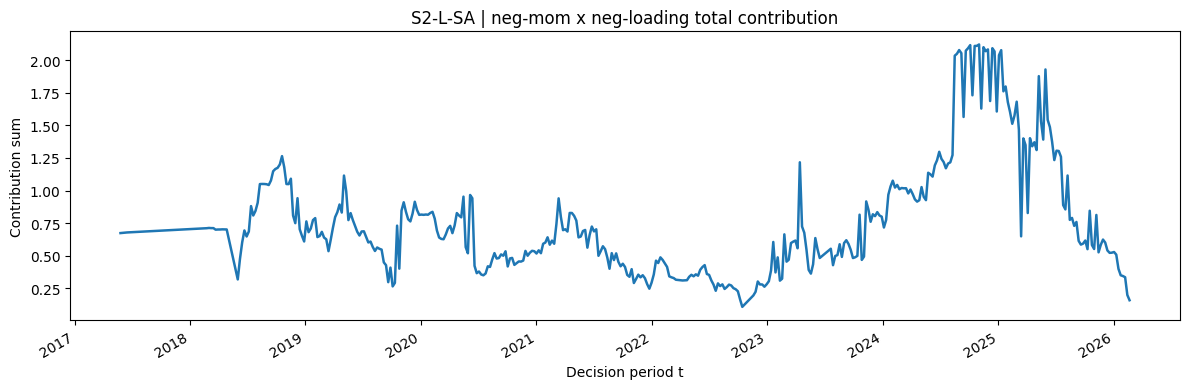

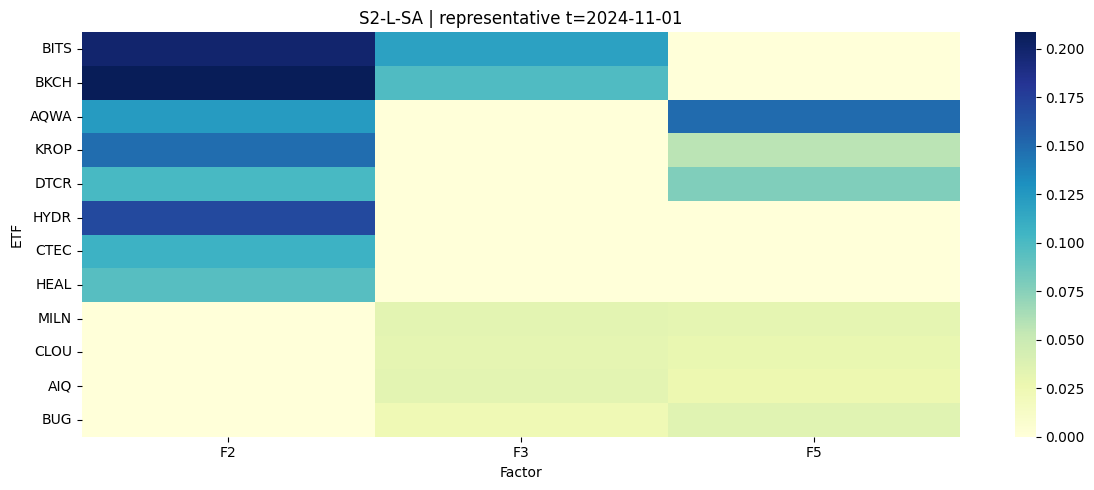

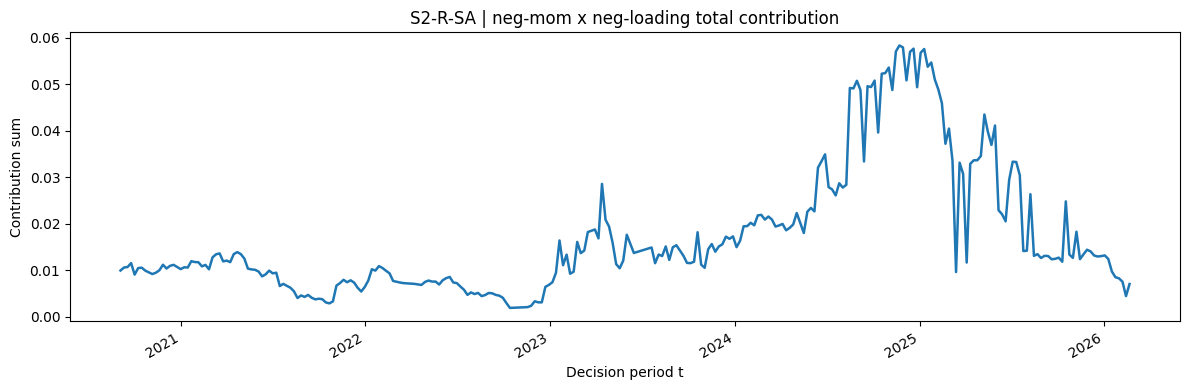

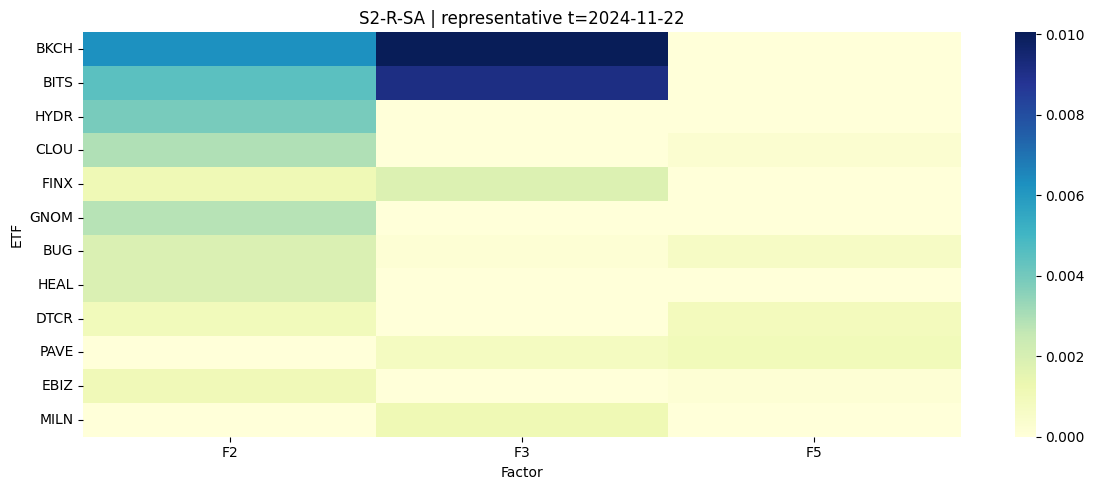

In [36]:
def analyze_negative_mom_negative_loading_contrib(exposure_by_t, signal_by_t):
    """
    contrib_{etf,factor} = exposure * signal のうち、
    signal<0 かつ exposure<0 の寄与だけを集計。
    """
    totals = {}
    matrix_by_t = {}

    for t, exposure_t in exposure_by_t.items():
        if t not in signal_by_t:
            continue

        signal_t = signal_by_t[t]
        fac = exposure_t.columns.intersection(signal_t.index)
        if len(fac) == 0:
            continue

        signal_sub = signal_t.loc[fac]
        neg_fac = signal_sub[signal_sub < 0].index
        if len(neg_fac) == 0:
            continue

        exp_sub = exposure_t[neg_fac]
        sig_sub = signal_t.loc[neg_fac]

        contrib = exp_sub.mul(sig_sub, axis=1)
        negneg_contrib = contrib.where(exp_sub < 0, 0.0)

        totals[t] = float(negneg_contrib.to_numpy().sum())
        matrix_by_t[t] = negneg_contrib

    total_s = pd.Series(totals, dtype=float).sort_index()
    total_s.name = 'neg_mom_x_neg_loading_contrib'

    if len(total_s) == 0:
        return total_s, None, pd.DataFrame(), matrix_by_t

    representative_t = total_s.idxmax()
    representative_matrix = matrix_by_t[representative_t]
    return total_s, representative_t, representative_matrix, matrix_by_t


def plot_negneg_diagnostics(total_s, representative_t, representative_matrix, title_prefix):
    if len(total_s) == 0:
        print(f'[WARN] {title_prefix}: no neg×neg contribution records.')
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    total_s.plot(ax=ax, linewidth=1.8, color='tab:blue')
    ax.set_title(f'{title_prefix} | neg-mom x neg-loading total contribution')
    ax.set_ylabel('Contribution sum')
    ax.set_xlabel('Decision period t')
    plt.tight_layout()
    plt.show()

    if representative_t is None or representative_matrix.empty:
        print(f'[WARN] {title_prefix}: representative heatmap is empty.')
        return

    mat = representative_matrix.copy()
    mat = mat.loc[mat.sum(axis=1) > 0, mat.sum(axis=0) > 0]
    if mat.empty:
        print(f'[WARN] {title_prefix}: no positive cells for heatmap.')
        return

    top_rows = mat.sum(axis=1).sort_values(ascending=False).head(12).index
    mat_plot = mat.loc[top_rows]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(mat_plot, cmap='YlGnBu', ax=ax)
    ax.set_title(f'{title_prefix} | representative t={representative_t.date()}')
    ax.set_xlabel('Factor')
    ax.set_ylabel('ETF')
    plt.tight_layout()
    plt.show()


negneg_s2l_sa, rep_t_l, rep_mat_l, negneg_mat_by_t_l = analyze_negative_mom_negative_loading_contrib(
    diag_s2l_sa['exposure_by_t'],
    diag_s2l_sa['signal_by_t'],
)

negneg_s2r_sa, rep_t_r, rep_mat_r, negneg_mat_by_t_r = analyze_negative_mom_negative_loading_contrib(
    diag_s2r_sa['exposure_by_t'],
    diag_s2r_sa['signal_by_t'],
)

plot_negneg_diagnostics(negneg_s2l_sa, rep_t_l, rep_mat_l, 'S2-L-SA')
plot_negneg_diagnostics(negneg_s2r_sa, rep_t_r, rep_mat_r, 'S2-R-SA')


## 18) フル比較マトリクス実行


In [37]:
compare_methods = [str(m).lower() for m in CONFIG.get('compare_weight_methods', [])]

matrix_weights_by_strategy = {}
matrix_diag_by_strategy = {}
matrix_skip_by_strategy = {}

matrix_gross_by_strategy = {}
matrix_net_by_strategy = {}
matrix_turnover_by_strategy = {}
matrix_equity_by_strategy = {}
matrix_dd_by_strategy = {}


def _merge_matrix_result(res):
    matrix_weights_by_strategy.update(res['weights_by_method'])
    matrix_diag_by_strategy.update(res['diag_by_method'])
    matrix_skip_by_strategy.update(res['skip_count_by_method'])


def _run_matrix_pass(heat_mode='none', suffix=None):
    s2l_matrix = run_sign_aware_matrix(
        decision_times=sorted(loadings_by_t.keys()),
        factor_mom=factor_mom,
        all_tickers=all_tickers,
        exposure_getter=get_exposure_elig_s2l,
        methods=compare_methods,
        config=CONFIG,
        runtime_ext=RUNTIME_EX,
        strategy_prefix='S2L_SA',
        exposure_model=None,
        heat_mode=heat_mode,
        vol_p=vol_p,
        strategy_suffix=suffix,
    )
    _merge_matrix_result(s2l_matrix)

    for model in CONFIG.get('s2r_exposure_models', ['ridge', 'lasso', 'nnls']):
        getter = get_exposure_elig_s2r_regularized_factory(model)
        s2r_matrix = run_sign_aware_matrix(
            decision_times=sorted(factor_mom.index),
            factor_mom=factor_mom,
            all_tickers=all_tickers,
            exposure_getter=getter,
            methods=compare_methods,
            config=CONFIG,
            runtime_ext=RUNTIME_EX,
            strategy_prefix='S2R_SA',
            exposure_model=model,
            heat_mode=heat_mode,
            vol_p=vol_p,
            strategy_suffix=suffix,
        )
        _merge_matrix_result(s2r_matrix)


if CONFIG.get('run_sign_aware', True) and len(compare_methods) > 0:
    _run_matrix_pass(heat_mode='none', suffix=None)

    if CONFIG.get('run_theme_heat_variants', True):
        _run_matrix_pass(heat_mode='theme_heat', suffix=CONFIG.get('heat_suffix', 'HEAT'))

for name, w_df in matrix_weights_by_strategy.items():
    gross_s, net_s, turn_s, eq_s, dd_s = run_backtest(w_df, ret_p, CONFIG['cost_bps'])
    matrix_gross_by_strategy[name] = gross_s
    matrix_net_by_strategy[name] = net_s
    matrix_turnover_by_strategy[name] = turn_s
    matrix_equity_by_strategy[name] = eq_s
    matrix_dd_by_strategy[name] = dd_s

summary_rows = []
for name in sorted(matrix_weights_by_strategy.keys()):
    diag = matrix_diag_by_strategy.get(name, {})
    mv_attempt = int(diag.get('mv_attempt_count', 0))
    mv_fallback = int(diag.get('mv_fallback_count', 0))
    mv_fallback_rate = (mv_fallback / mv_attempt) if mv_attempt > 0 else 0.0

    hg = pd.Series(diag.get('heat_global_by_t', {}), dtype=float)
    heat_mean = float(hg.mean()) if len(hg) > 0 else 0.0

    summary_rows.append({
        'strategy': name,
        'heat_mode': diag.get('heat_mode', 'none'),
        'decision_periods': len(matrix_weights_by_strategy[name]),
        'net_periods': len(matrix_net_by_strategy.get(name, pd.Series(dtype=float))),
        'skipped': matrix_skip_by_strategy.get(name, 0),
        'mv_fallback_rate': mv_fallback_rate,
        'heat_global_mean': heat_mean,
    })

summary_df = pd.DataFrame(summary_rows).set_index('strategy').sort_index() if summary_rows else pd.DataFrame()
print('Full matrix strategy summary:')
display(summary_df)

# Lasso / NNLS の疎性確認（exposure係数のゼロ比率）
sparsity_rows = []
for name, diag in matrix_diag_by_strategy.items():
    if ('_LASSO_' not in name) and ('_NNLS_' not in name):
        continue

    vals = []
    for _, exp_raw in diag.get('exposure_raw_by_t', {}).items():
        if exp_raw is None or exp_raw.empty:
            continue
        arr = exp_raw.values.astype(float).ravel()
        arr = arr[np.isfinite(arr)]
        if len(arr) > 0:
            vals.append(arr)

    if len(vals) == 0:
        continue

    merged = np.concatenate(vals)
    zero_ratio = float((np.abs(merged) < 1e-10).mean())

    sparsity_rows.append({
        'strategy': name,
        'coef_count': int(len(merged)),
        'zero_ratio': zero_ratio,
        'mean_abs_coef': float(np.mean(np.abs(merged))),
    })

sparsity_df = pd.DataFrame(sparsity_rows).set_index('strategy').sort_values('zero_ratio', ascending=False) if sparsity_rows else pd.DataFrame()
print('Lasso/NNLS exposure sparsity:')
display(sparsity_df)

# Heat値域と戦略本数チェック
base_names = [k for k in matrix_weights_by_strategy if not k.endswith(f"_{str(CONFIG.get('heat_suffix', 'HEAT')).upper()}")]
heat_names = [k for k in matrix_weights_by_strategy if k.endswith(f"_{str(CONFIG.get('heat_suffix', 'HEAT')).upper()}")]
print(f'Base strategy count: {len(base_names)}')
print(f'Heat strategy count: {len(heat_names)}')

if CONFIG.get('run_theme_heat_variants', True):
    assert len(base_names) == len(heat_names), 'Heat strategy count mismatch with base strategies.'

all_heat_vals = []
for name in heat_names:
    diag = matrix_diag_by_strategy.get(name, {})
    hg = pd.Series(diag.get('heat_global_by_t', {}), dtype=float)
    if len(hg) > 0:
        all_heat_vals.append(hg.values)
    for _, hl in diag.get('heat_local_by_t', {}).items():
        if hl is None:
            continue
        vals = hl.values.astype(float)
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            all_heat_vals.append(vals)

if len(all_heat_vals) > 0:
    merged_heat = np.concatenate(all_heat_vals)
    assert (merged_heat >= -1e-12).all() and (merged_heat <= 1.0 + 1e-12).all(), 'Heat values out of [0,1].'

# 単調性の基本チェック
_test = pd.Series([0.3, 0.8], index=['A', 'B'])
_low = apply_heat_to_signal(_test, 0.1, CONFIG)
_high = apply_heat_to_signal(_test, 0.9, CONFIG)
assert (_high.abs() <= _low.abs() + 1e-12).all(), 'Signal heat monotonicity failed.'

_test_sig = pd.Series([0.4, 0.6], index=['A', 'B'])
_hl_low = pd.Series([0.1, 0.1], index=['A', 'B'])
_hl_high = pd.Series([0.9, 0.9], index=['A', 'B'])
_sc_low = apply_heat_to_allocation_score(_test_sig, _hl_low, CONFIG)
_sc_high = apply_heat_to_allocation_score(_test_sig, _hl_high, CONFIG)
assert (_sc_high.abs() <= _sc_low.abs() + 1e-12).all(), 'Allocation heat monotonicity failed.'

print('Heat integration sanity checks passed.')


Full matrix strategy summary:


,decision_periods,net_periods,skipped,mv_fallback_rate
strategy,,,,
S2L_SA_MEANVARIANCE_TC,504,503,52,0.0
S2L_SA_PROPORTIONAL,504,503,52,0.0
S2L_SA_TOPK_EQUAL,504,503,52,0.0
S2L_SA_VOL_ADJUSTED,504,503,52,0.0
S2R_SA_LASSO_MEANVARIANCE_TC,287,286,528,0.0
S2R_SA_LASSO_PROPORTIONAL,287,286,528,0.0
S2R_SA_LASSO_TOPK_EQUAL,287,286,528,0.0
S2R_SA_LASSO_VOL_ADJUSTED,287,286,528,0.0
S2R_SA_NNLS_MEANVARIANCE_TC,268,267,547,0.0


Lasso/NNLS exposure sparsity:


,coef_count,zero_ratio,mean_abs_coef
strategy,,,
S2R_SA_NNLS_PROPORTIONAL,41512,0.398246,0.003296
S2R_SA_NNLS_TOPK_EQUAL,41512,0.398246,0.003296
S2R_SA_NNLS_VOL_ADJUSTED,41512,0.398246,0.003296
S2R_SA_NNLS_MEANVARIANCE_TC,41512,0.398246,0.003296
S2R_SA_LASSO_PROPORTIONAL,45160,0.219885,0.003536
S2R_SA_LASSO_TOPK_EQUAL,45160,0.219885,0.003536
S2R_SA_LASSO_VOL_ADJUSTED,45160,0.219885,0.003536
S2R_SA_LASSO_MEANVARIANCE_TC,45160,0.219885,0.003536


## 15) 既存戦略 vs Sign-Aware戦略 の同一期間比較


Sign-aware common window: 2020-09-11 -> 2026-02-27 (286 periods)


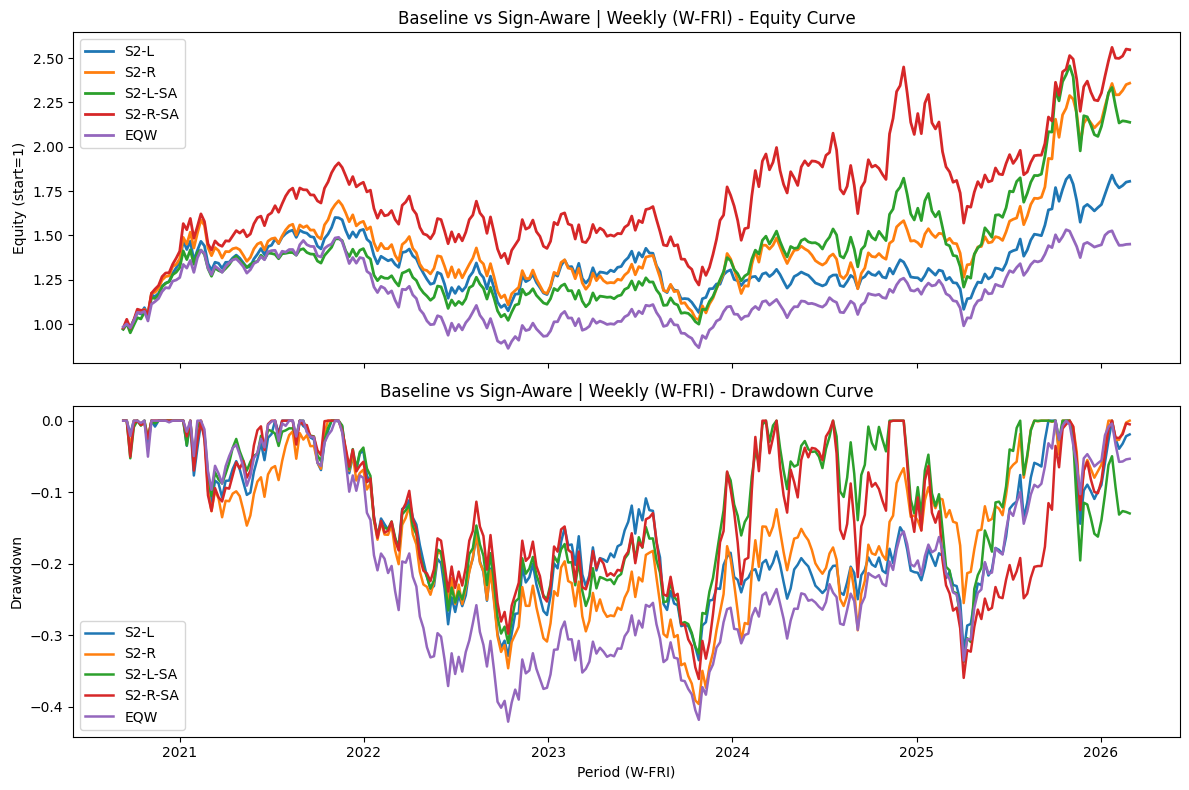

Performance metrics on sign-aware common window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
S2-L,0.113316,0.225876,0.588568,-0.334720,0.122119,0.520979
S2-R,0.168788,0.260140,0.729698,-0.395964,0.103925,0.538462
S2-L-SA,0.148127,0.261014,0.659596,-0.336973,0.140238,0.510490
S2-R-SA,0.185261,0.294763,0.723860,-0.360874,0.117386,0.527972
EQW,0.069945,0.222041,0.415403,-0.420529,0.002737,0.517483


Delta table (Sign-Aware - Baseline):


,Sharpe_delta,CAGR_delta,MDD_delta
S2-L-SA vs S2-L,0.071028,0.034811,-0.002253
S2-R-SA vs S2-R,-0.005838,0.016473,0.035090


In [38]:
common_idx_sa = (
    net_s2l.index
    .intersection(net_s2r.index)
    .intersection(net_s2l_sa.index)
    .intersection(net_s2r_sa.index)
    .intersection(eqw_net.index)
)

if len(common_idx_sa) == 0:
    raise ValueError('No common comparison period among baseline and sign-aware strategies.')

print(f'Sign-aware common window: {common_idx_sa.min().date()} -> {common_idx_sa.max().date()} ({len(common_idx_sa)} periods)')

net_compare = {
    'S2-L': net_s2l.reindex(common_idx_sa),
    'S2-R': net_s2r.reindex(common_idx_sa),
    'S2-L-SA': net_s2l_sa.reindex(common_idx_sa),
    'S2-R-SA': net_s2r_sa.reindex(common_idx_sa),
    'EQW': eqw_net.reindex(common_idx_sa),
}

turn_compare = {
    'S2-L': turnover_s2l.reindex(common_idx_sa),
    'S2-R': turnover_s2r.reindex(common_idx_sa),
    'S2-L-SA': turnover_s2l_sa.reindex(common_idx_sa),
    'S2-R-SA': turnover_s2r_sa.reindex(common_idx_sa),
    'EQW': eqw_turnover.reindex(common_idx_sa),
}

equity_compare = {k: (1.0 + v).cumprod() for k, v in net_compare.items()}
dd_compare = {k: calc_drawdown(v) for k, v in equity_compare.items()}

plot_equity_dd(
    equity_map=equity_compare,
    dd_map=dd_compare,
    title_prefix=f"Baseline vs Sign-Aware | {RUNTIME['frequency_label']}",
)

metrics_compare = pd.DataFrame({
    k: calc_metrics(net_compare[k], turn_compare[k], RUNTIME['periods_per_year']) for k in net_compare
}).T

print('Performance metrics on sign-aware common window:')
display(metrics_compare)

improve_table = pd.DataFrame({
    'Sharpe_delta': [
        metrics_compare.loc['S2-L-SA', 'Sharpe'] - metrics_compare.loc['S2-L', 'Sharpe'],
        metrics_compare.loc['S2-R-SA', 'Sharpe'] - metrics_compare.loc['S2-R', 'Sharpe'],
    ],
    'CAGR_delta': [
        metrics_compare.loc['S2-L-SA', 'CAGR'] - metrics_compare.loc['S2-L', 'CAGR'],
        metrics_compare.loc['S2-R-SA', 'CAGR'] - metrics_compare.loc['S2-R', 'CAGR'],
    ],
    'MDD_delta': [
        metrics_compare.loc['S2-L-SA', 'MDD'] - metrics_compare.loc['S2-L', 'MDD'],
        metrics_compare.loc['S2-R-SA', 'MDD'] - metrics_compare.loc['S2-R', 'MDD'],
    ],
}, index=['S2-L-SA vs S2-L', 'S2-R-SA vs S2-R'])

print('Delta table (Sign-Aware - Baseline):')
display(improve_table)


## 19) 共通期間比較（全戦略）


All-strategy common window: 2020-09-11 -> 2026-02-27 (267 periods)
Active strategy count: 21
Sharpe ranking (all strategies):


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
S2R_SA_NNLS_TOPK_EQUAL,0.155226,0.242947,0.716073,-0.328941,0.128714,0.550562
S2R_SA_LASSO_TOPK_EQUAL,0.153494,0.252069,0.692817,-0.348210,0.098502,0.546816
S2R_SA_NNLS_PROPORTIONAL,0.151924,0.254521,0.683152,-0.354675,0.119994,0.528090
S2R_SA_RIDGE_TOPK_EQUAL,0.147329,0.250697,0.673819,-0.348945,0.105243,0.543071
S2R_SA_NNLS_VOL_ADJUSTED,0.129987,0.226005,0.654128,-0.317075,0.122800,0.550562
S2R_SA_LASSO_VOL_ADJUSTED,0.138997,0.245847,0.652536,-0.343107,0.119413,0.531835
S2R_SA_RIDGE_VOL_ADJUSTED,0.133376,0.240425,0.641240,-0.328481,0.119875,0.535581
S2R_SA_RIDGE_PROPORTIONAL,0.147161,0.282707,0.626860,-0.369598,0.110778,0.531835
S2R_SA_LASSO_PROPORTIONAL,0.150446,0.291360,0.626451,-0.388369,0.110888,0.531835
S2-R,0.133290,0.257447,0.614522,-0.395964,0.104579,0.535581


Delta vs baseline:


,baseline,Sharpe_delta,CAGR_delta,MDD_delta
strategy,,,,
S2R_SA_NNLS_TOPK_EQUAL,S2-R,0.101551,0.021936,0.067023
S2R_SA_LASSO_TOPK_EQUAL,S2-R,0.078295,0.020204,0.047754
S2R_SA_NNLS_PROPORTIONAL,S2-R,0.068630,0.018634,0.041289
S2L_SA_VOL_ADJUSTED,S2-L,0.059523,0.010641,0.059239
S2R_SA_RIDGE_TOPK_EQUAL,S2-R,0.059296,0.014039,0.047019
S2R_SA_NNLS_VOL_ADJUSTED,S2-R,0.039605,-0.003303,0.078889
S2R_SA_LASSO_VOL_ADJUSTED,S2-R,0.038014,0.005708,0.052857
S2L_SA_TOPK_EQUAL,S2-L,0.033403,0.021328,0.042012
S2R_SA_RIDGE_VOL_ADJUSTED,S2-R,0.026718,0.000086,0.067483


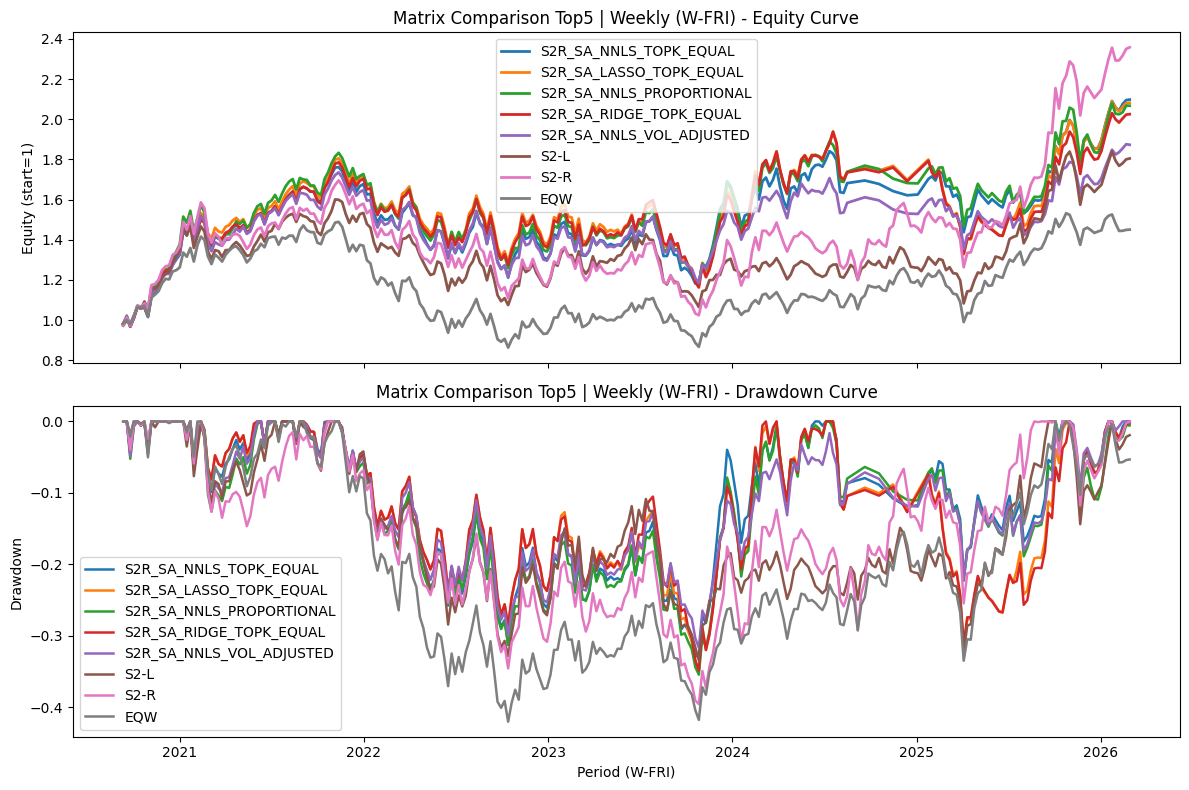

In [44]:
all_net_by_strategy = {
    'S2-L': net_s2l,
    'S2-R': net_s2r,
    'EQW': eqw_net,
    'S2-L-SA': net_s2l_sa,
    'S2-R-SA': net_s2r_sa,
}

all_turnover_by_strategy = {
    'S2-L': turnover_s2l,
    'S2-R': turnover_s2r,
    'EQW': eqw_turnover,
    'S2-L-SA': turnover_s2l_sa,
    'S2-R-SA': turnover_s2r_sa,
}

all_net_by_strategy.update(matrix_net_by_strategy)
all_turnover_by_strategy.update(matrix_turnover_by_strategy)

active_strategies = [k for k, v in all_net_by_strategy.items() if isinstance(v, pd.Series) and len(v) > 0]
if len(active_strategies) == 0:
    raise ValueError('No active strategy series found for matrix comparison.')

common_idx_all = None
for k in active_strategies:
    idx = all_net_by_strategy[k].index
    common_idx_all = idx if common_idx_all is None else common_idx_all.intersection(idx)

if common_idx_all is None or len(common_idx_all) == 0:
    raise ValueError('No common comparison period across all active strategies.')

print(f'All-strategy common window: {common_idx_all.min().date()} -> {common_idx_all.max().date()} ({len(common_idx_all)} periods)')
print(f'Active strategy count: {len(active_strategies)}')

metrics_raw = pd.DataFrame({
    k: calc_metrics(
        net_ret=all_net_by_strategy[k].reindex(common_idx_all),
        turnover=all_turnover_by_strategy[k].reindex(common_idx_all),
        periods_per_year=RUNTIME['periods_per_year'],
    )
    for k in active_strategies
}).T

metrics_matrix = metrics_raw.replace([np.inf, -np.inf], np.nan).fillna(0.0)
assert np.isfinite(metrics_matrix.values).all(), 'metrics_matrix contains NaN/inf after sanitation.'

rank_table = metrics_matrix.sort_values('Sharpe', ascending=False)
print('Sharpe ranking (all strategies):')
display(rank_table)

# Baseline差分（S2L系はS2-L、S2R系はS2-R を参照）
delta_rows = []
for name in rank_table.index:
    if name.startswith('S2L_SA_') and 'S2-L' in rank_table.index:
        base = 'S2-L'
    elif name.startswith('S2R_SA_') and 'S2-R' in rank_table.index:
        base = 'S2-R'
    else:
        continue

    delta_rows.append({
        'strategy': name,
        'baseline': base,
        'Sharpe_delta': rank_table.loc[name, 'Sharpe'] - rank_table.loc[base, 'Sharpe'],
        'CAGR_delta': rank_table.loc[name, 'CAGR'] - rank_table.loc[base, 'CAGR'],
        'MDD_delta': rank_table.loc[name, 'MDD'] - rank_table.loc[base, 'MDD'],
    })

delta_vs_baseline = pd.DataFrame(delta_rows).set_index('strategy').sort_values('Sharpe_delta', ascending=False) if delta_rows else pd.DataFrame()
print('Delta vs baseline:')
display(delta_vs_baseline)

# Heat有無ペア差分（HEAT - BASE）
heat_suffix = f"_{str(CONFIG.get('heat_suffix', 'HEAT')).upper()}"
heat_pair_rows = []

for name in metrics_matrix.index:
    if name.endswith(heat_suffix):
        continue
    heat_name = name + heat_suffix
    if heat_name not in metrics_matrix.index:
        continue

    heat_pair_rows.append({
        'strategy_base': name,
        'strategy_heat': heat_name,
        'Sharpe_delta_heat': metrics_matrix.loc[heat_name, 'Sharpe'] - metrics_matrix.loc[name, 'Sharpe'],
        'CAGR_delta_heat': metrics_matrix.loc[heat_name, 'CAGR'] - metrics_matrix.loc[name, 'CAGR'],
        'MDD_delta_heat': metrics_matrix.loc[heat_name, 'MDD'] - metrics_matrix.loc[name, 'MDD'],
        'Turnover_delta_heat': metrics_matrix.loc[heat_name, 'Turnover'] - metrics_matrix.loc[name, 'Turnover'],
    })

heat_pair_delta = pd.DataFrame(heat_pair_rows).set_index('strategy_base').sort_values('Sharpe_delta_heat', ascending=False) if heat_pair_rows else pd.DataFrame()
print('Heat effect table (HEAT - BASE):')
display(heat_pair_delta)

# TopN戦略のみ可視化
n_top = min(8, len(rank_table))
top_names = rank_table.head(n_top).index.tolist()

equity_top = {
    k: (1.0 + all_net_by_strategy[k].reindex(common_idx_all)).cumprod()
    for k in top_names
}
dd_top = {k: calc_drawdown(v) for k, v in equity_top.items()}

plot_equity_dd(
    equity_map=equity_top,
    dd_map=dd_top,
    title_prefix=f'Matrix Comparison Top{n_top} | {RUNTIME["frequency_label"]}',
)


## 20) 負mom×負exposure寄与の横断比較


Cross-strategy neg-mom x neg-exposure stats:


,mean,median,p90,max,obs
strategy,,,,,
S2-L-SA,0.762285,0.674219,1.340841,2.122535,410
S2L_SA_PROPORTIONAL,0.762285,0.674219,1.340841,2.122535,410
S2L_SA_TOPK_EQUAL,0.762285,0.674219,1.340841,2.122535,410
S2L_SA_VOL_ADJUSTED,0.762285,0.674219,1.340841,2.122535,410
S2L_SA_MEANVARIANCE_TC,0.762285,0.674219,1.340841,2.122535,410
S2R_SA_RIDGE_TOPK_EQUAL,0.017954,0.013127,0.042711,0.060584,274
S2R_SA_RIDGE_VOL_ADJUSTED,0.017954,0.013127,0.042711,0.060584,274
S2R_SA_RIDGE_MEANVARIANCE_TC,0.017954,0.013127,0.042711,0.060584,274
S2R_SA_RIDGE_PROPORTIONAL,0.017954,0.013127,0.042711,0.060584,274


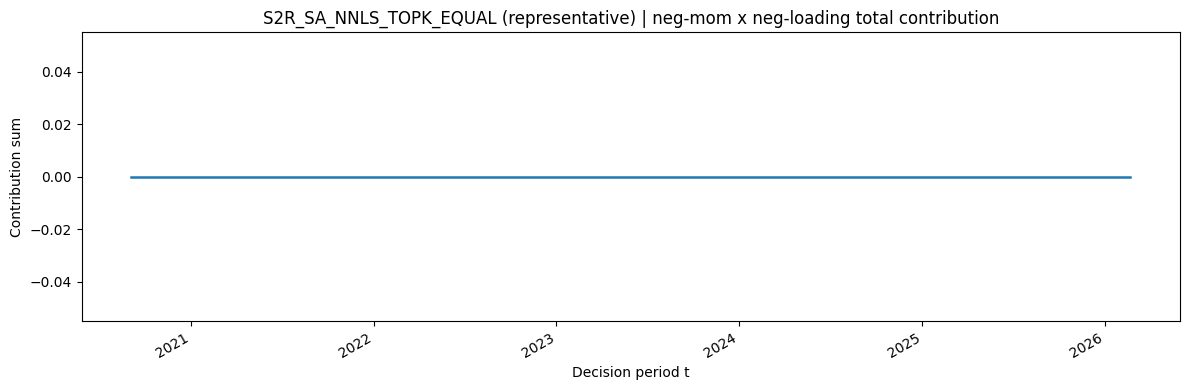

[WARN] S2R_SA_NNLS_TOPK_EQUAL (representative): no positive cells for heatmap.


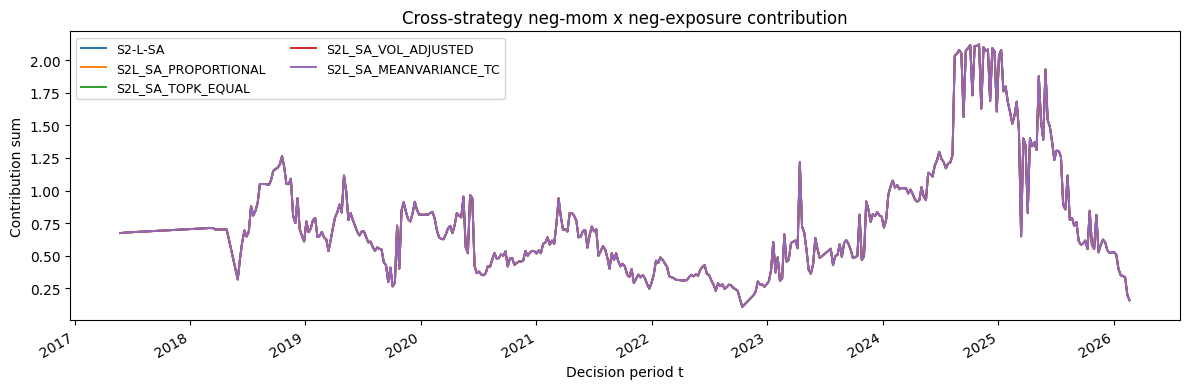

In [40]:
diag_for_negneg = {
    'S2-L-SA': diag_s2l_sa,
    'S2-R-SA': diag_s2r_sa,
}
diag_for_negneg.update(matrix_diag_by_strategy)

negneg_total_by_strategy = {}
negneg_rep_by_strategy = {}

for name, diag in diag_for_negneg.items():
    total_s, rep_t, rep_mat, _ = analyze_negative_mom_negative_loading_contrib(
        diag.get('exposure_by_t', {}),
        diag.get('signal_by_t', {}),
    )
    negneg_total_by_strategy[name] = total_s
    negneg_rep_by_strategy[name] = (rep_t, rep_mat)

stats_rows = []
for name, s in negneg_total_by_strategy.items():
    if len(s) == 0:
        continue
    stats_rows.append({
        'strategy': name,
        'mean': float(s.mean()),
        'median': float(s.median()),
        'p90': float(s.quantile(0.9)),
        'max': float(s.max()),
        'obs': int(len(s)),
    })

negneg_stats = pd.DataFrame(stats_rows).set_index('strategy').sort_values('mean', ascending=False) if stats_rows else pd.DataFrame()
print('Cross-strategy neg-mom x neg-exposure stats:')
display(negneg_stats)

# Heat有無のnegneg統計差分
heat_suffix = f"_{str(CONFIG.get('heat_suffix', 'HEAT')).upper()}"
heat_neg_rows = []
for name in negneg_stats.index:
    if name.endswith(heat_suffix):
        continue
    heat_name = name + heat_suffix
    if heat_name not in negneg_stats.index:
        continue

    heat_neg_rows.append({
        'strategy_base': name,
        'strategy_heat': heat_name,
        'mean_delta_heat': negneg_stats.loc[heat_name, 'mean'] - negneg_stats.loc[name, 'mean'],
        'median_delta_heat': negneg_stats.loc[heat_name, 'median'] - negneg_stats.loc[name, 'median'],
        'p90_delta_heat': negneg_stats.loc[heat_name, 'p90'] - negneg_stats.loc[name, 'p90'],
        'max_delta_heat': negneg_stats.loc[heat_name, 'max'] - negneg_stats.loc[name, 'max'],
    })

heat_negneg_delta = pd.DataFrame(heat_neg_rows).set_index('strategy_base').sort_values('mean_delta_heat', ascending=False) if heat_neg_rows else pd.DataFrame()
print('Neg-neg contribution delta (HEAT - BASE):')
display(heat_negneg_delta)

if len(negneg_stats) > 0:
    rank_candidates = [x for x in rank_table.index if x in negneg_stats.index]
    rep_name = rank_candidates[0] if len(rank_candidates) > 0 else negneg_stats.index[0]
    rep_t, rep_mat = negneg_rep_by_strategy[rep_name]
    plot_negneg_diagnostics(negneg_total_by_strategy[rep_name], rep_t, rep_mat, f'{rep_name} (representative)')

    top_cmp = negneg_stats.head(min(5, len(negneg_stats))).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 4))
    for name in top_cmp:
        negneg_total_by_strategy[name].plot(ax=ax, linewidth=1.4, label=name)
    ax.set_title('Cross-strategy neg-mom x neg-exposure contribution')
    ax.set_xlabel('Decision period t')
    ax.set_ylabel('Contribution sum')
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()
